# Quantum Geostatistics and Artificial Intelligence: A New Approach for Spatial Data Analysis
## (*Computers & Geosciences*)

This notebook reproduces every number, table and figure of the revised manuscript.

* **Real geophysical data.** Gravity and magnetic residual grids of the Hajjar polymetallic ore body
  (Guemassa massif, Morocco; Soulaimani et al., 2020), 86 x 210 nodes at 14.4 m spacing
  (1224 m x 3010 m). The full survey is the ground truth; sparse subsets of stations are the inputs.
* **Synthetic analogue matched to the real survey.** Same grid, same extent, and a correlation length
  (300 m) that reproduces the Gaussian variogram range of the real gravity residual (about 370 m).
* **Fair classical baselines.** Ordinary kriging with data-driven selection among Gaussian, exponential,
  Matern(3/2) and spherical models (weighted least squares); Gaussian processes with RBF, Matern(3/2)
  and anisotropic (ARD) kernels fitted by marginal likelihood; a random forest with spatial
  buffer-distance features (RFsp) and tuned hyperparameters.
* **Nested cross-validation.** Every hyperparameter (variogram model and parameters, GP length scale and
  noise, the quantum register itself: number of qubits in {4,5,6}, layers in {2,3}, bandwidth beta; the hybrid
  weight alpha in [0,1] and RBF scale; random-forest settings) is chosen inside the training folds only.
* **Repeated experiments and statistics.** Several field realisations / station subsets per experiment;
  mean and standard deviation of RMSE, MAE and R^2; paired Wilcoxon signed-rank tests.
* **Uncertainty calibration.** 95% prediction-interval coverage, CRPS and negative log predictive density.
* **Sensitivity, ablation and diagnostics.** Number of stations, correlation length, noise level, sampling
  design; entanglement, number of qubits, number of layers, bandwidth; kernel eigenvalues, rank and
  condition number; anisotropic and non-stationary fields with a formal location-dependence diagnostic.

The quantum feature map is simulated exactly (noiseless state vectors) with **QuTiP**; a vectorised
encoder, verified against QuTiP to machine precision, is used for bulk encoding.
All randomness is seeded.

## 0. Environment

In [ ]:
# %pip install qutip numpy scipy scikit-learn matplotlib
import numpy as np, matplotlib.pyplot as plt, time, warnings
from matplotlib import gridspec
from matplotlib.patches import FancyBboxPatch
import qutip
print("QuTiP", qutip.__version__)
plt.rcParams.update({"font.size":10.5,"axes.titlesize":11,"axes.labelsize":10.5,"figure.dpi":105,
                     "savefig.dpi":300,"savefig.bbox":"tight","axes.spines.top":False,"axes.spines.right":False})
warnings.filterwarnings("ignore")
SEEDS_MAIN=6; SEEDS_SENS=3; SEEDS_FIELD=4; SEEDS_ABL=3    # repetitions used in the paper

QuTiP 5.3.1


## 1. Library: data, synthetic fields, sampling designs, geostatistics, quantum feature map, GP, RF, uncertainty, nested CV
The functions below are also shipped as `qgeo.py` in the public repository.

In [ ]:
"""
Quantum geostatistics: core library.
Synthetic + real (Hajjar) data; matched extent; nested CV; uncertainty; diagnostics.
"""
from __future__ import annotations
import numpy as np, re, time, warnings
from scipy.spatial.distance import cdist
from scipy.optimize import least_squares
from scipy.special import kv, gamma as gfun
from scipy.stats import norm, wilcoxon
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as CK, WhiteKernel
from sklearn.cluster import KMeans
from qutip import basis, tensor, sigmax, sigmay, sigmaz, qeye
warnings.filterwarnings("ignore")

In [3]:
# ----------------------------------------------------------------------
# 0. Real data (Hajjar, Soulaimani et al., 2020)
# ----------------------------------------------------------------------
def load_survey(path):
    X,Y,V,L=[],[],[],[]; line=None
    for raw in open(path, encoding="utf-8", errors="ignore"):
        s=raw.strip()
        if not s: continue
        m=re.match(r"^Line\s+(\d+)", s)
        if m: line=int(m.group(1)); continue
        p=s.split()
        if len(p)>=4:
            try: x,y,v=float(p[0]),float(p[1]),float(p[3])
            except ValueError: continue
            X.append(x);Y.append(y);V.append(v);L.append(line)
    X,Y,V,L=map(np.asarray,(X,Y,V,L))
    ux=np.unique(np.round(X,1)); uy=np.unique(np.round(Y,1))
    return dict(X=X,Y=Y,V=V,line=L,nx=len(ux),ny=len(uy),
                dx=float(np.median(np.diff(ux))), dy=float(np.median(np.diff(uy))),
                x0=X.min(),y0=Y.min(),Lx=X.max()-X.min(),Ly=Y.max()-Y.min())

def survey_to_grid(d):
    """Return (xs, ys, Z[ny,nx]) in physical metres; NaN where missing."""
    xs=np.unique(np.round(d["X"],1)); ys=np.unique(np.round(d["Y"],1))
    Z=np.full((len(ys),len(xs)),np.nan)
    ix=np.searchsorted(xs,np.round(d["X"],1)); iy=np.searchsorted(ys,np.round(d["Y"],1))
    Z[iy,ix]=d["V"]
    return xs,ys,Z

In [4]:
# ----------------------------------------------------------------------
# 1. Synthetic fields on a physical grid (matched to the Hajjar window)
# ----------------------------------------------------------------------
def grf_gaussian(nx, ny, dx, ell, seed, anis=None, pad=2):
    """
    Stationary Gaussian random field with covariance C(h)=exp(-h^2/ell^2)
    (Gaussian model) on an ny x nx grid with spacing dx (metres).
    anis=(ell_u, ell_v, theta_deg): anisotropic Gaussian covariance
    exp(-(u^2/ell_u^2 + v^2/ell_v^2)) in axes rotated by theta.
    Spectral synthesis with zero-padding to suppress wrap-around.
    """
    r=np.random.default_rng(seed)
    Nx,Ny=pad*nx,pad*ny
    kx=np.fft.fftfreq(Nx,d=dx); ky=np.fft.fftfreq(Ny,d=dx)
    KX,KY=np.meshgrid(kx,ky)
    if anis is None:
        S=np.exp(-(np.pi*ell)**2*(KX**2+KY**2))
    else:
        eu,ev,th=anis; t=np.deg2rad(th)
        KU= KX*np.cos(t)+KY*np.sin(t); KV=-KX*np.sin(t)+KY*np.cos(t)
        S=np.exp(-np.pi**2*(eu**2*KU**2+ev**2*KV**2))
    noise=r.normal(size=(Ny,Nx))+1j*r.normal(size=(Ny,Nx))
    F=np.fft.ifft2(noise*np.sqrt(S)).real[:ny,:nx]
    return (F-F.mean())/F.std()

def grf_nonstationary(nx, ny, dx, ell_west, ell_east, seed, width_frac=0.15):
    """Locally varying correlation length: smooth blend of two stationary fields."""
    F1=grf_gaussian(nx,ny,dx,ell_west,seed)
    F2=grf_gaussian(nx,ny,dx,ell_east,seed+1000)
    x=np.linspace(0,1,nx)[None,:]*np.ones((ny,1))
    w=1/(1+np.exp((x-0.5)/width_frac))          # 1 in the west, 0 in the east
    F=w*F1+(1-w)*F2
    return (F-F.mean())/F.std()

def make_grid(nx,ny,dx,x0=0.0,y0=0.0):
    xs=x0+dx*np.arange(nx); ys=y0+dx*np.arange(ny)
    XX,YY=np.meshgrid(xs,ys)
    return xs,ys,np.column_stack([XX.ravel(),YY.ravel()])

In [5]:
# ----------------------------------------------------------------------
# 2. Sampling designs
# ----------------------------------------------------------------------
def sample_design(grid, n, design, seed, nx=None, ny=None):
    r=np.random.default_rng(seed); N=len(grid)
    if design=="random":
        return r.choice(N,n,replace=False)
    if design=="clustered":
        k=max(3,n//30); centers=r.choice(N,k,replace=False)
        span=np.ptp(grid,axis=0).max()
        idx=[]
        for c in centers:
            d=np.linalg.norm(grid-grid[c],axis=1)
            p=np.exp(-(d/(0.08*span))**2); p/=p.sum()
            idx+=list(r.choice(N,n//k,replace=False,p=p))
        idx=np.unique(idx)
        while len(idx)<n: idx=np.unique(np.append(idx,r.choice(N)))
        return idx[:n]
    if design=="lines":
        # keep every k-th survey line and every m-th station along a line
        assert nx and ny
        ii=np.arange(N); row=ii//nx; col=ii%nx
        step_l=max(1,int(round(ny/np.sqrt(n*ny/nx)))); step_p=max(1,int(round(nx/np.sqrt(n*nx/ny))))
        m=(row%step_l==0)&(col%step_p==0)
        idx=ii[m]
        if len(idx)>n: idx=r.choice(idx,n,replace=False)
        return idx
    raise ValueError(design)

In [6]:
# ----------------------------------------------------------------------
# 3. Variogram models (practical-range convention), WLS fit, model selection
# ----------------------------------------------------------------------
def experimental_variogram(P,z,nlags=15,hmax=None):
    D=cdist(P,P); dz2=0.5*(z[:,None]-z[None,:])**2
    iu=np.triu_indices_from(D,1); d,v=D[iu],dz2[iu]
    if hmax is None: hmax=0.6*d.max()
    edges=np.linspace(0,hmax,nlags+1); c,g,npairs=[],[],[]
    for a,b in zip(edges[:-1],edges[1:]):
        m=(d>=a)&(d<b)
        if m.sum()>=5: c.append(0.5*(a+b)); g.append(v[m].mean()); npairs.append(m.sum())
    return np.array(c),np.array(g),np.array(npairs)

def directional_variogram(P,z,angle_deg,tol_deg=22.5,nlags=12,hmax=None):
    D=cdist(P,P); dz2=0.5*(z[:,None]-z[None,:])**2
    dxm=P[:,0][None,:]-P[:,0][:,None]; dym=P[:,1][None,:]-P[:,1][:,None]
    ang=np.degrees(np.arctan2(dym,dxm))%180
    iu=np.triu_indices_from(D,1); d,v,a=D[iu],dz2[iu],ang[iu]
    da=np.minimum(np.abs(a-angle_deg),180-np.abs(a-angle_deg))
    sel=da<=tol_deg; d,v=d[sel],v[sel]
    if hmax is None: hmax=0.6*D.max()
    edges=np.linspace(0,hmax,nlags+1); c,g=[],[]
    for lo,hi in zip(edges[:-1],edges[1:]):
        m=(d>=lo)&(d<hi)
        if m.sum()>=5: c.append(0.5*(lo+hi)); g.append(v[m].mean())
    return np.array(c),np.array(g)

def _matern(h,a,nu):
    # correlation with practical range a (95%): scale so that rho(a)=0.05 approximately
    # use scaling factor kappa(nu) computed numerically once
    kappa={0.5:3.0,1.5:4.744,2.5:5.918}[nu]
    x=kappa*h/a; x=np.where(x<1e-12,1e-12,x)
    return (2**(1-nu)/gfun(nu))*(x**nu)*kv(nu,x)

VARIO_MODELS={
 "gaussian":   lambda h,a: 1-np.exp(-3*h**2/a**2),
 "exponential":lambda h,a: 1-np.exp(-3*h/a),
 "matern15":   lambda h,a: 1-_matern(h,a,1.5),
 "spherical":  lambda h,a: np.where(h<a,1.5*h/a-0.5*(h/a)**3,1.0),
}
def vmodel(h,params,model):
    c0,c,a=params; return c0+c*VARIO_MODELS[model](h,a)

def fit_variogram(hc,gc,npairs,model,hmax):
    def res(p):
        return np.sqrt(npairs)*(vmodel(hc,p,model)-gc)/(gc+1e-9)   # Cressie-style weights
    best=None
    for a0 in [0.15*hmax,0.3*hmax,0.6*hmax]:
        p0=[0.05*gc.max(),0.95*gc.max(),a0]
        r=least_squares(res,p0,bounds=([0,1e-6,0.02*hmax],[gc.max(),5*gc.max(),4*hmax]))
        if best is None or r.cost<best.cost: best=r
    return best.x,best.cost

def select_variogram(P,z,models=("gaussian","exponential","matern15","spherical"),nlags=15):
    hc,gc,npairs=experimental_variogram(P,z,nlags)
    hmax=hc.max(); fits={}
    for m in models:
        p,cost=fit_variogram(hc,gc,npairs,m,hmax); fits[m]=(p,cost)
    best=min(fits,key=lambda m:fits[m][1])
    return best,fits,hc,gc

In [7]:
# ----------------------------------------------------------------------
# 4. Kriging (ordinary, with Lagrange constraint) and GP predictors
# ----------------------------------------------------------------------
def ordinary_kriging(P_obs,z_obs,P_pred,params,model,jitter=1e-3):
    c0,c,a=params; n=len(P_obs)
    C=(c0+c)-vmodel(cdist(P_obs,P_obs),params,model); np.fill_diagonal(C,c0+c)
    C=C+jitter*(c0+c)*np.eye(n)          # numerical nugget (Gaussian model is ill-conditioned)
    A=np.ones((n+1,n+1)); A[:n,:n]=C; A[n,n]=0
    Cp=(c0+c)-vmodel(cdist(P_pred,P_obs),params,model)
    B=np.ones((n+1,len(P_pred))); B[:n,:]=Cp.T
    try: W=np.linalg.solve(A,B)
    except np.linalg.LinAlgError: W=np.linalg.lstsq(A,B,rcond=None)[0]
    zp=W[:n,:].T@z_obs
    var=(c0+c)-np.einsum("ij,ji->i",W.T,B)
    return zp,np.sqrt(np.clip(var,1e-12,None))

def gp_fit_predict(K_tr,K_ts,k_ts_diag,y,sig_f,sig_n,jitter=1e-8):
    """Simple kriging with estimated constant mean (GP with constant mean).
    Returns mean and predictive std (incl. noise). K's are correlation matrices (unit diag)."""
    n=len(y); mu=y.mean()
    A=sig_f*K_tr+(sig_n+jitter)*np.eye(n)
    L=np.linalg.cholesky(A)
    alpha=np.linalg.solve(L.T,np.linalg.solve(L,y-mu))
    m=sig_f*K_ts@alpha+mu
    v=np.linalg.solve(L,(sig_f*K_ts).T)
    var=sig_f*k_ts_diag-np.sum(v**2,axis=0)+sig_n
    return m,np.sqrt(np.clip(var,1e-12,None))

def gp_nll(K,y,sig_f,sig_n,jitter=1e-8):
    n=len(y); mu=y.mean(); A=sig_f*K+(sig_n+jitter)*np.eye(n)
    try: L=np.linalg.cholesky(A)
    except np.linalg.LinAlgError: return np.inf
    a=np.linalg.solve(L,y-mu)
    return 0.5*a@a+np.log(np.diag(L)).sum()+0.5*n*np.log(2*np.pi)

def ml_fit_scale_noise(K,y,sf_grid=None,sn_grid=None):
    """Type-II ML on a log grid for amplitude and noise variance (kernel shape fixed)."""
    v=np.var(y)
    if sf_grid is None: sf_grid=v*np.logspace(-1,1,7)
    if sn_grid is None: sn_grid=v*np.logspace(-4,0,9)
    best=(np.inf,None,None)
    for sf in sf_grid:
        for sn in sn_grid:
            nll=gp_nll(K,y,sf,sn)
            if nll<best[0]: best=(nll,sf,sn)
    return best[1],best[2],best[0]

def rbf_corr(A,B,ell): return np.exp(-cdist(A,B)**2/(2*ell**2))

In [8]:
# ----------------------------------------------------------------------
# 5. Quantum feature map (QuTiP reference) and verified fast encoder
# ----------------------------------------------------------------------
def _Ry(t): return (-1j*(t/2)*sigmay()).expm()
def _Rz(t): return (-1j*(t/2)*sigmaz()).expm()
def _cnot(nq,c,t):
    P0=basis(2,0)*basis(2,0).dag(); P1=basis(2,1)*basis(2,1).dag()
    a=[qeye(2)]*nq; b=[qeye(2)]*nq; a[c]=P0; b[c]=P1; b[t]=sigmax()
    return tensor(a)+tensor(b)

def feature_state_qutip(x,y,nq=4,reps=2,beta=1.5,entangle=True):
    """Reference implementation with QuTiP (state-vector simulation)."""
    CN=[_cnot(nq,i,(i+1)%nq) for i in range(nq)]
    psi=tensor([basis(2,0)]*nq); feats=[x,y]
    for _ in range(reps):
        for q in range(nq):
            g=[qeye(2)]*nq; g[q]=_Ry(beta*(q+1)*feats[q%2]); psi=tensor(g)*psi
        if entangle:
            for q in range(nq): psi=CN[q]*psi
        for q in range(nq):
            g=[qeye(2)]*nq; g[q]=_Rz(beta*(q+1)*feats[q%2]); psi=tensor(g)*psi
    return psi.unit().full().ravel()

class FastEncoder:
    """Vectorised state-vector encoder (identical to feature_state_qutip to ~1e-16).
    Precomputes the constant ring-CNOT operator; applies rotation layers per point."""
    def __init__(self,nq=4,reps=2,beta=1.5,entangle=True):
        self.nq,self.reps,self.beta,self.ent=nq,reps,beta,entangle
        I=np.eye(2,dtype=complex); X=np.array([[0,1],[1,0]],dtype=complex)
        P0=np.diag([1,0]).astype(complex); P1=np.diag([0,1]).astype(complex)
        def kron_list(L):
            M=L[0]
            for k in range(1,len(L)): M=np.kron(M,L[k])
            return M
        U=np.eye(2**nq,dtype=complex)
        for q in range(nq):
            a=[I]*nq; b=[I]*nq; a[q]=P0; b[q]=P1; b[(q+1)%nq]=X
            U=(kron_list(a)+kron_list(b))@U
        self.Ucnot=U if entangle else np.eye(2**nq,dtype=complex)
    def _rot_layer(self,isY,feats):
        # returns (npts, 2^nq, 2^nq) batched tensor-product of single-qubit rotations
        npts=feats.shape[0]; U=np.ones((npts,1,1),dtype=complex)
        for q in range(self.nq):
            th=self.beta*(q+1)*feats[:,q%2]
            c,s=np.cos(th/2),np.sin(th/2)
            if isY:
                g=np.zeros((npts,2,2),dtype=complex); g[:,0,0]=c; g[:,0,1]=-s; g[:,1,0]=s; g[:,1,1]=c
            else:
                e=np.exp(-1j*th/2); g=np.zeros((npts,2,2),dtype=complex); g[:,0,0]=e; g[:,1,1]=np.conj(e)
            U=np.einsum("nij,nkl->nikjl",U,g).reshape(npts,U.shape[1]*2,U.shape[2]*2)
        return U
    def states(self,P,chunk=1500):
        P=np.asarray(P,float)
        if len(P)>chunk:   # bounded memory for large point sets (6 qubits: 64x64 per point)
            return np.vstack([self.states(P[i:i+chunk],chunk) for i in range(0,len(P),chunk)])
        npts=len(P); dim=2**self.nq
        psi=np.zeros((npts,dim),dtype=complex); psi[:,0]=1
        for _ in range(self.reps):
            Ry=self._rot_layer(True,P); psi=np.einsum("nij,nj->ni",Ry,psi)
            psi=psi@self.Ucnot.T
            Rz=self._rot_layer(False,P); psi=np.einsum("nij,nj->ni",Rz,psi)
        return psi/np.linalg.norm(psi,axis=1,keepdims=True)

def fidelity_kernel(SA,SB): return np.abs(SA@SB.conj().T)**2

def kernel_diagnostics(K,jitter=1e-8):
    w=np.linalg.eigvalsh(K); wmin,wmax=w.min(),w.max()
    return dict(min_eig=float(wmin),max_eig=float(wmax),
                cond=float(wmax/max(wmin,1e-300)),
                cond_jitter=float((wmax+jitter)/(max(wmin,0)+jitter)),
                rank=int((w>1e-10*wmax).sum()),symmetric=bool(np.allclose(K,K.T)),
                unit_diag=bool(np.allclose(np.diag(K),1)))

In [9]:
# ----------------------------------------------------------------------
# 6. Random forest with spatial buffer-distance features (RFsp, Hengl 2018)
# ----------------------------------------------------------------------
def rfsp_features(P,anchors): return np.hstack([P,cdist(P,anchors)])

def fit_rf(Ptr,ztr,seed,n_anchors=20,inner_folds=3):
    k=min(n_anchors,len(Ptr))
    anchors=KMeans(k,n_init=3,random_state=seed).fit(Ptr).cluster_centers_
    Ftr=rfsp_features(Ptr,anchors)
    grid=[(leaf,mf) for leaf in (1,5) for mf in ("sqrt",1.0)]
    best=(np.inf,None); kf=KFold(inner_folds,shuffle=True,random_state=seed)
    for leaf,mf in grid:
        err=[]
        for a,b in kf.split(Ftr):
            m=RandomForestRegressor(100,min_samples_leaf=leaf,max_features=mf,random_state=seed,n_jobs=-1).fit(Ftr[a],ztr[a])
            err.append(np.mean((m.predict(Ftr[b])-ztr[b])**2))
        if np.mean(err)<best[0]: best=(np.mean(err),(leaf,mf))
    leaf,mf=best[1]
    model=RandomForestRegressor(300,min_samples_leaf=leaf,max_features=mf,random_state=seed,n_jobs=-1).fit(Ftr,ztr)
    return model,anchors,dict(min_samples_leaf=leaf,max_features=mf)

In [10]:
# ----------------------------------------------------------------------
# 7. Uncertainty scores
# ----------------------------------------------------------------------
def coverage95(y,m,s): return float(np.mean(np.abs(y-m)<=1.96*s))
def nlpd(y,m,s): return float(np.mean(0.5*np.log(2*np.pi*s**2)+0.5*((y-m)/s)**2))
def crps_gauss(y,m,s):
    z=(y-m)/s; return float(np.mean(s*(z*(2*norm.cdf(z)-1)+2*norm.pdf(z)-1/np.sqrt(np.pi))))

In [11]:
# ----------------------------------------------------------------------
# 8. Nested cross-validation for all methods
# ----------------------------------------------------------------------
_STAGE1={}
NQ_GRID=(4,5,6); REPS_GRID=(2,3); BETA_GRID=(2.0,2.5,3.0,3.5); ALPHA_GRID=(0.0,0.25,0.5,0.75,1.0); ELL_GRID=(0.05,0.1)
METHODS=["OK","GP-RBF","GP-Matern","GP-ARD","RF","Quantum","Hybrid"]

def _inner_cv_select(Ptr,ztr,candidates,build,inner_folds=3,seed=0):
    """Generic inner CV: candidates -> (K_tr, K_ts builder). Selects by inner RMSE."""
    kf=KFold(inner_folds,shuffle=True,random_state=seed); best=(np.inf,None)
    for cand in candidates:
        err=[]
        for a,b in kf.split(Ptr):
            Ka,Kab,diag_b=build(cand,Ptr[a],Ptr[b])
            sf,sn,_=ml_fit_scale_noise(Ka,ztr[a])
            m,_=gp_fit_predict(Ka,Kab,diag_b,ztr[a],sf,sn)
            err.append(np.mean((m-ztr[b])**2))
        if np.mean(err)<best[0]: best=(np.mean(err),cand)
    return best[1]

def run_method(method,Ptr,ztr,Pte,scale_len,seed=0,nq=4,reps=2,entangle=True,
               beta_grid=(1.5,2.0,2.5,3.0,3.5,4.0),alpha_grid=(0.25,0.5,0.75),ell_grid=(0.05,0.1,0.2),
               inner_folds=3):
    """Train on (Ptr,ztr) with hyperparameters chosen INSIDE the training set; predict Pte.
    Coordinates in metres; kernels use coordinates scaled by scale_len (same for x,y).
    Returns mean, std, info dict."""
    info={}
    Str,Ste=Ptr/scale_len,Pte/scale_len
    if method=="OK":
        best,fits,_,_=select_variogram(Ptr,ztr)
        m,s=ordinary_kriging(Ptr,ztr,Pte,fits[best][0],best)
        info=dict(model=best,params=fits[best][0])
        return m,s,info
    if method in ("GP-RBF","GP-Matern","GP-ARD"):
        if method=="GP-RBF":   base=RBF(0.2,(1e-3,10.0))
        elif method=="GP-Matern": base=Matern(0.2,(1e-3,10.0),nu=1.5)
        else:                  base=RBF([0.2,0.2],(1e-3,10.0))     # anisotropic (ARD) RBF
        k=CK(np.var(ztr),(1e-3,1e3))*base+WhiteKernel(0.05*np.var(ztr),(1e-6,1e1))
        gp=GaussianProcessRegressor(k,normalize_y=True,n_restarts_optimizer=2,random_state=seed).fit(Str,ztr)
        m,s=gp.predict(Ste,return_std=True)
        info=dict(kernel=str(gp.kernel_))
        return m,s,info
    if method=="RF":
        model,anchors,hp=fit_rf(Ptr,ztr,seed,inner_folds=inner_folds)
        Fte=rfsp_features(Pte,anchors); m=model.predict(Fte)
        # quantile-free uncertainty proxy: spread across trees
        allp=np.stack([t.predict(Fte) for t in model.estimators_]); s=allp.std(axis=0)+1e-6
        info=dict(hyper=hp); return m,s,info
    if method in ("Quantum","Hybrid"):
        # Stage 1 (shared): select the register (nq, layers, beta) by inner CV on the quantum kernel alone
        key=(round(float(Str.sum()),6),len(Str),seed,tuple(NQ_GRID),tuple(REPS_GRID),tuple(BETA_GRID))
        if key not in _STAGE1:
            cands=[(q,r,b) for q in NQ_GRID for r in REPS_GRID for b in BETA_GRID]
            def build(c,A,B):
                q,r,b=c; enc=FastEncoder(q,r,b,entangle); SA,SB=enc.states(A),enc.states(B)
                return fidelity_kernel(SA,SA),fidelity_kernel(SB,SA),np.ones(len(B))
            _STAGE1[key]=_inner_cv_select(Str,ztr,cands,build,inner_folds,seed)
        q,r,b=_STAGE1[key]
        enc=FastEncoder(q,r,b,entangle); SA,SB=enc.states(Str),enc.states(Ste)
        KQ=fidelity_kernel(SA,SA); KQts=fidelity_kernel(SB,SA)
        if method=="Quantum":
            sf,sn,_=ml_fit_scale_noise(KQ,ztr)
            m,s=gp_fit_predict(KQ,KQts,np.ones(len(Ste)),ztr,sf,sn)
            return m,s,dict(nq=q,reps=r,beta=b,sig_f=sf,sig_n=sn,diag=kernel_diagnostics(KQ))
        # Stage 2: select the mixing weight and RBF scale (alpha=0 -> pure RBF, alpha=1 -> pure quantum)
        cands=[(a,l) for a in ALPHA_GRID for l in ELL_GRID]
        def build2(c,A,B):
            a,l=c; encA=FastEncoder(q,r,b,entangle); SA2,SB2=encA.states(A),encA.states(B)
            return a*fidelity_kernel(SA2,SA2)+(1-a)*rbf_corr(A,A,l), a*fidelity_kernel(SB2,SA2)+(1-a)*rbf_corr(B,A,l), np.ones(len(B))
        a,l=_inner_cv_select(Str,ztr,cands,build2,inner_folds,seed)
        K=a*KQ+(1-a)*rbf_corr(Str,Str,l); Kts=a*KQts+(1-a)*rbf_corr(Ste,Str,l)
        sf,sn,_=ml_fit_scale_noise(K,ztr)
        m,s=gp_fit_predict(K,Kts,np.ones(len(Ste)),ztr,sf,sn)
        return m,s,dict(nq=q,reps=r,beta=b,alpha=a,ell=l,sig_f=sf,sig_n=sn)
    raise ValueError(method)

def nested_cv(P,z,scale_len,methods=METHODS,outer=10,seed=0,**kw):
    kf=KFold(outer,shuffle=True,random_state=seed); out={}
    for meth in methods:
        yt,yp,ys,infos,t0=[],[],[],[],time.time()
        for tr,te in kf.split(P):
            m,s,info=run_method(meth,P[tr],z[tr],P[te],scale_len,seed=seed,**kw)
            yt.append(z[te]); yp.append(m); ys.append(s); infos.append(info)
        yt,yp,ys=map(np.concatenate,(yt,yp,ys))
        r=dict(rmse=float(np.sqrt(np.mean((yt-yp)**2))),mae=float(np.mean(np.abs(yt-yp))),
               r2=float(1-np.sum((yt-yp)**2)/np.sum((yt-yt.mean())**2)),
               cov95=coverage95(yt,yp,ys),nlpd=nlpd(yt,yp,ys),crps=crps_gauss(yt,yp,ys),
               time=time.time()-t0,yt=yt,yp=yp,ys=ys,infos=infos)
        out[meth]=r
    return out

def summarize(runs,methods=METHODS,keys=("rmse","mae","r2","cov95","crps","nlpd","time")):
    """runs: list of nested_cv outputs (one per seed) -> mean/std table"""
    tab={}
    for m in methods:
        tab[m]={k:(np.mean([r[m][k] for r in runs]),np.std([r[m][k] for r in runs])) for k in keys}
    return tab

def paired_test(runs,a,b,key="rmse"):
    xa=np.array([r[a][key] for r in runs]); xb=np.array([r[b][key] for r in runs])
    if np.allclose(xa,xb): return 1.0,float(np.mean(xa-xb))
    try: p=wilcoxon(xa,xb).pvalue
    except ValueError: p=1.0
    return float(p),float(np.mean(xa-xb))

In [12]:
# ----------------------------------------------------------------------
# 9. Ablation of the quantum feature map (beta re-tuned per configuration)
# ----------------------------------------------------------------------
def ablation_quantum(P,z,scale_len,configs,outer=5,seed=0,beta_grid=(1.0,1.5,2.0,2.5,3.0,3.5,4.0,5.0,6.0)):
    """configs: list of dict(nq,reps,entangle). Returns {label: (rmse, r2, best_betas)}."""
    S=P/scale_len; kf=KFold(outer,shuffle=True,random_state=seed); out={}
    for cfg in configs:
        yt,yp,betas=[],[],[]
        for tr,te in kf.split(S):
            def build(beta,A,B):
                enc=FastEncoder(cfg["nq"],cfg["reps"],beta,cfg["entangle"]); SA,SB=enc.states(A),enc.states(B)
                return fidelity_kernel(SA,SA),fidelity_kernel(SB,SA),np.ones(len(B))
            beta=_inner_cv_select(S[tr],z[tr],beta_grid,build,3,seed)
            enc=FastEncoder(cfg["nq"],cfg["reps"],beta,cfg["entangle"]); SA,SB=enc.states(S[tr]),enc.states(S[te])
            K=fidelity_kernel(SA,SA); Kts=fidelity_kernel(SB,SA)
            sf,sn,_=ml_fit_scale_noise(K,z[tr]); m,_=gp_fit_predict(K,Kts,np.ones(len(te)),z[tr],sf,sn)
            yt.append(z[te]); yp.append(m); betas.append(beta)
        yt,yp=np.concatenate(yt),np.concatenate(yp)
        lab=f"nq={cfg['nq']}, L={cfg['reps']}, ent={'on' if cfg['entangle'] else 'off'}"
        out[lab]=dict(rmse=float(np.sqrt(np.mean((yt-yp)**2))),
                      r2=float(1-np.sum((yt-yp)**2)/np.sum((yt-yt.mean())**2)),betas=betas)
    return out

In [13]:
# ----------------------------------------------------------------------
# 10. Normal-score transform (for skewed real data, e.g. magnetic residual)
# ----------------------------------------------------------------------
class NormalScore:
    """Rank-based Gaussian anamorphosis fitted on training values only."""
    def fit(self,v):
        self.sorted=np.sort(np.asarray(v,float)); n=len(self.sorted)
        self.q=norm.ppf((np.arange(1,n+1)-0.5)/n); return self
    def transform(self,v):
        return np.interp(v,self.sorted,self.q,left=self.q[0],right=self.q[-1])
    def inverse(self,y):
        return np.interp(y,self.q,self.sorted,left=self.sorted[0],right=self.sorted[-1])

In [14]:
# ----------------------------------------------------------------------
# 11. Non-stationarity diagnostic for a kernel: how much of the kernel value
#     at a given distance is explained by WHERE the pair sits (eta-squared)
# ----------------------------------------------------------------------
def kernel_location_dependence(P,K,nbins_h=12,nbins_loc=4):
    """Returns eta^2: fraction of residual kernel variance (after removing the
    mean kernel-vs-distance trend) explained by the location of the pair midpoint."""
    D=cdist(P,P); iu=np.triu_indices(len(P),1); d=D[iu]; k=K[iu]
    mid=0.5*(P[iu[0]]+P[iu[1]])
    hb=np.digitize(d,np.linspace(0,d.max()*1.0001,nbins_h+1))-1
    resid=np.empty_like(k)
    for b in np.unique(hb):
        m=hb==b; resid[m]=k[m]-k[m].mean()
    lx=np.digitize(mid[:,0],np.linspace(P[:,0].min(),P[:,0].max()*1.0001,nbins_loc+1))-1
    ly=np.digitize(mid[:,1],np.linspace(P[:,1].min(),P[:,1].max()*1.0001,nbins_loc+1))-1
    cell=lx*nbins_loc+ly
    ss_tot=np.sum((resid-resid.mean())**2); ss_between=0.0
    for c in np.unique(cell):
        m=cell==c; ss_between+=m.sum()*(resid[m].mean()-resid.mean())**2
    return float(ss_between/max(ss_tot,1e-12))

## 2. Real data: Hajjar gravity and magnetic residual grids

The two files hold the residual gravity anomaly (mGal) and the reduced residual magnetic anomaly (nT)
over the Hajjar ore body (Soulaimani et al., 2020), on a regular 86 x 210 grid (14.4 m). The dense
survey plays the role of the ground truth; sparse station subsets are the inputs to the predictors.

In [15]:
grav=load_survey("GRAV_RES.txt"); mag=load_survey("MAG_RES_REDUIT.txt")
for name,d in (("Gravity residual (mGal)",grav),("Magnetic residual, reduced (nT)",mag)):
    v=d["V"]; zs=(v-v.mean())/v.std()
    print(f"{name}: {d['nx']}x{d['ny']} nodes, dx={d['dx']:.1f} m, extent {d['Lx']:.0f} x {d['Ly']:.0f} m, "
          f"min={v.min():.3f} max={v.max():.3f} mean={v.mean():.3f} std={v.std():.3f}, "
          f"skew={(zs**3).mean():.2f}, kurt={(zs**4).mean()-3:.2f}")
NX,NY,DX=grav["nx"],grav["ny"],grav["dx"]
XS,YS,GRID=make_grid(NX,NY,DX)           # physical metres, origin at the SW corner
L0=max(XS.max(),YS.max())               # common scaling length for the kernels (3010 m)
print("Grid nodes:",len(GRID),"| scaling length L0 =",round(L0,1),"m")

Gravity residual (mGal): 86x210 nodes, dx=14.4 m, extent 1224 x 3010 m, min=-0.387 max=0.481 mean=0.000 std=0.151, skew=0.19, kurt=-0.51
Magnetic residual, reduced (nT): 86x210 nodes, dx=14.4 m, extent 1224 x 3010 m, min=-235.034 max=1030.152 mean=-141.989 std=151.090, skew=3.96, kurt=18.00
Grid nodes: 18060 | scaling length L0 = 3009.6 m


In [16]:
# Figure helpers: HD export, panel labels, tight layout
import matplotlib as mpl
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":9,"axes.labelsize":9,"legend.fontsize":7.5,"xtick.labelsize":8,"ytick.labelsize":8,
                     "axes.spines.top":False,"axes.spines.right":False,"figure.dpi":100})
def savefig_hd(name,fig=None):
    """Export HD JPEG at 1000 dpi (for submission) and a 300-dpi PNG (for the Word file)."""
    fig=fig or plt.gcf()
    fig.savefig(f"{name}.jpeg",dpi=1000,format="jpeg",bbox_inches="tight",pad_inches=0.02,pil_kwargs={"quality":92,"optimize":True})
    fig.savefig(f"{name}.png",dpi=300,bbox_inches="tight",pad_inches=0.02)
def label(ax,s,color="k",inside=True,dx=0.02,dy=0.98):
    if inside: ax.text(dx,dy,f"({s})",transform=ax.transAxes,ha="left",va="top",fontsize=10,fontweight="bold",color=color,
                       bbox=dict(boxstyle="round,pad=0.15",fc="white",ec="none",alpha=0.75))
    else: ax.text(-0.02,1.03,f"({s})",transform=ax.transAxes,ha="right",va="bottom",fontsize=10,fontweight="bold",color=color)
def map_panel(ax,Z,cmap="viridis",vmin=None,vmax=None,pts=None,cb_label="",xl=True,yl=True,cb=True):
    im=ax.imshow(Z.reshape(NY,NX),origin="lower",extent=[0,XS.max(),0,YS.max()],cmap=cmap,vmin=vmin,vmax=vmax,aspect="equal")
    if pts is not None: ax.scatter(pts[:,0],pts[:,1],s=6,c="white",edgecolors="k",lw=.3,zorder=3)
    ax.set_xlabel("Easting (m)" if xl else ""); ax.set_ylabel("Northing (m)" if yl else "")
    if not xl: ax.set_xticklabels([])
    if not yl: ax.set_yticklabels([])
    if cb:
        c=plt.colorbar(im,ax=ax,fraction=0.075,pad=0.02); c.set_label(cb_label,fontsize=8); c.ax.tick_params(labelsize=7)
    return im
cols={"OK":"#566573","GP-RBF":"#2874a6","GP-Matern":"#1b4f72","GP-ARD":"#5dade2","RF":"#117a65","Quantum":"#b03a2e","Hybrid":"#7d3c98"}


## 3. Synthetic analogue on the Hajjar geometry

A stationary Gaussian random field with Gaussian covariance $C(h)=\exp(-h^2/\ell^2)$ is synthesised on the
**same 86 x 210 grid and 14.4 m spacing** as the survey. With $\ell = 300$ m the field has a practical
variogram range $a=\sqrt{3}\,\ell \approx 520$ m; because the window is only about four correlation lengths
wide and the field is standardised within it, the range recovered from data is shorter (about 380 m),
which matches the range of the real gravity residual (about 370 m). The empirical autocorrelation of
the generator is checked below.

lag 150 m: empirical rho=0.766  target exp(-(h/ell)^2)=0.779
lag 300 m: empirical rho=0.292  target exp(-(h/ell)^2)=0.368
lag 450 m: empirical rho=0.026  target exp(-(h/ell)^2)=0.105
lag 600 m: empirical rho=-0.063  target exp(-(h/ell)^2)=0.018


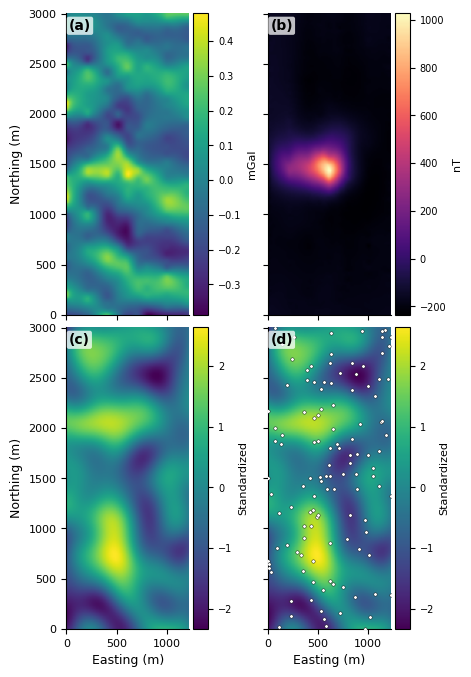

In [17]:
ELL=300.0
def synthetic_case(seed,n=120,ell=ELL,noise=0.08,design="random",anis=None,nonstat=None):
    if nonstat is not None: F=grf_nonstationary(NX,NY,DX,nonstat[0],nonstat[1],seed)
    else:                    F=grf_gaussian(NX,NY,DX,ell,seed,anis=anis)
    z_true=F.ravel(); idx=sample_design(GRID,n,design,seed,nx=NX,ny=NY)
    z=z_true[idx]+np.random.default_rng(seed).normal(0,noise,len(idx))
    return z_true,idx,GRID[idx],z
# empirical autocorrelation of the generator (20 realisations)
rhos=[]
for s in range(20):
    F=grf_gaussian(NX,NY,DX,ELL,s); F=(F-F.mean())/F.std(); r=[]
    for lag in (150,300,450,600):
        k=int(round(lag/DX)); r.append(0.5*(np.mean(F[:,:-k]*F[:,k:])+np.mean(F[:-k,:]*F[k:,:])))
    rhos.append(r)
for lag,rho in zip((150,300,450,600),np.mean(rhos,0)):
    print(f"lag {lag:3d} m: empirical rho={rho:.3f}  target exp(-(h/ell)^2)={np.exp(-(lag/ELL)**2):.3f}")
_,_,ZG=survey_to_grid(grav); _,_,ZM=survey_to_grid(mag)
z_true0,idx0,P0,z0=synthetic_case(7)
fig,axs=plt.subplots(2,2,figsize=(5.2,8.0))
map_panel(axs[0,0],ZG.ravel(),cb_label="mGal",xl=False); label(axs[0,0],"a")
map_panel(axs[0,1],ZM.ravel(),cmap="magma",cb_label="nT",xl=False,yl=False); label(axs[0,1],"b")
map_panel(axs[1,0],z_true0,cb_label="Standardized"); label(axs[1,0],"c")
map_panel(axs[1,1],z_true0,pts=P0,cb_label="Standardized",yl=False); label(axs[1,1],"d")
plt.subplots_adjust(wspace=0.0,hspace=0.04); savefig_hd("fig1_data"); plt.show()

In [18]:
# Cross-check of the experimental variogram and Gaussian-model fit with GSTools (Mueller et al., 2022)
try:
    import gstools as gs
    bins=np.linspace(0,0.6*cdist(P0,P0).max(),16)
    bc,gv=gs.vario_estimate((P0[:,0],P0[:,1]),z0,bins)
    model=gs.Gaussian(dim=2); model.fit_variogram(bc,gv,nugget=True)
    hc_,gc_,_=experimental_variogram(P0,z0,15); best_,fits_,_,_=select_variogram(P0,z0)
    print(f"GSTools Gaussian fit: len_scale={model.len_scale:.0f} m -> practical range (95%) = {model.len_scale*np.sqrt(3):.0f} m, var={model.var:.2f}, nugget={model.nugget:.3f}")
    print(f"this study, Gaussian model : range={fits_['gaussian'][0][2]:.0f} m, sill={fits_['gaussian'][0][1]:.2f}, nugget={fits_['gaussian'][0][0]:.3f}")
    print("max |gamma_ours - gamma_gstools| on common lags:", float(np.max(np.abs(np.interp(hc_,bc,gv)-gc_))).__round__(3))
except Exception as e:
    print("gstools not available:",e)

GSTools Gaussian fit: len_scale=209 m -> practical range (95%) = 362 m, var=1.22, nugget=0.000
this study, Gaussian model : range=430 m, sill=1.19, nugget=0.000
max |gamma_ours - gamma_gstools| on common lags: 0.0


## 4. Quantum feature map, fidelity kernel and diagnostics

**Background.** A qubit is a two-level quantum system whose state is a unit vector
$|\psi\rangle=\alpha|0\rangle+\beta|1\rangle\in\mathbb{C}^2$ (Dirac ket notation). A register of $n_q$ qubits
lives in the tensor-product space $\mathbb{C}^{2^{n_q}}$. Single-qubit rotations are
$R_y(\theta)=\exp(-i\theta\sigma_y/2)$ and $R_z(\theta)=\exp(-i\theta\sigma_z/2)$ with the Pauli matrices
$\sigma_y,\sigma_z$; the controlled-NOT gate flips a target qubit conditionally on a control qubit and creates
entanglement (states that cannot be written as a product of single-qubit states).

**Feature map.** A location $\mathbf{s}=(x,y)$ (scaled by $L_0$) is encoded by $L$ layers of
$R_y$ rotations with angles $\beta(q{+}1)s_d$ (qubit $q$ reads $x$ or $y$ alternately, with an integer
frequency $q{+}1$), a ring of CNOTs, and $R_z$ rotations with the same angles. Re-uploading the data in
each layer makes the state a truncated Fourier series of $\mathbf{s}$ (Schuld et al., 2021).

**Kernel.** $K_Q(\mathbf{s},\mathbf{s}')=|\langle\phi(\mathbf{s})|\phi(\mathbf{s}')\rangle|^2$ is the squared
overlap (fidelity). It is symmetric, unit on the diagonal and positive semi-definite (it is a Gram matrix of
the vectors $|\phi\rangle\langle\phi|$). Its rank is at most $4^{n_q}$, a genuine capacity limit of a small
register. Intuitively, whereas an RBF kernel decays monotonically with distance, $K_Q$ is a sum of cosines of
the coordinate differences: it is intrinsically anisotropic (x and y enter with different frequencies) and,
if $\beta$ is too large, it concentrates towards the identity matrix and loses its ability to generalise.

In [19]:
# Verification: vectorised encoder == QuTiP reference
pts=np.random.default_rng(0).random((6,2))
for ent in (True,False):
    S=FastEncoder(4,2,3.0,ent).states(pts); Sq=np.array([feature_state_qutip(x,y,4,2,3.0,ent) for x,y in pts])
    print(f"entangle={ent}: max|1-fidelity(fast,QuTiP)| = {np.max(np.abs(1-np.abs(np.sum(S*Sq.conj(),1))**2)):.1e}")
t=time.time(); _=FastEncoder().states(GRID/L0); print(f"encoding all {len(GRID)} grid nodes: {time.time()-t:.1f} s")
# Kernel diagnostics on the 120 synthetic stations
S0=P0/L0
for beta in (1.5,3.0,6.0):
    K=fidelity_kernel(*(FastEncoder(4,2,beta).states(S0),)*2); dg=kernel_diagnostics(K)
    print(f"beta={beta}: min eig={dg['min_eig']:.2e} max eig={dg['max_eig']:.2f} rank={dg['rank']}/{len(S0)} "
          f"cond(no jitter)={dg['cond']:.1e} cond(jitter 1e-8)={dg['cond_jitter']:.1e} sym={dg['symmetric']} unit diag={dg['unit_diag']}")

entangle=True: max|1-fidelity(fast,QuTiP)| = 8.9e-16
entangle=False: max|1-fidelity(fast,QuTiP)| = 4.4e-16


encoding all 18060 grid nodes: 0.3 s
beta=1.5: min eig=5.85e-15 max eig=27.62 rank=98/120 cond(no jitter)=4.7e+15 cond(jitter 1e-8)=2.8e+09 sym=True unit diag=True
beta=3.0: min eig=1.16e-07 max eig=15.40 rank=120/120 cond(no jitter)=1.3e+08 cond(jitter 1e-8)=1.2e+08 sym=True unit diag=True
beta=6.0: min eig=2.09e-04 max eig=10.60 rank=120/120 cond(no jitter)=5.1e+04 cond(jitter 1e-8)=5.1e+04 sym=True unit diag=True


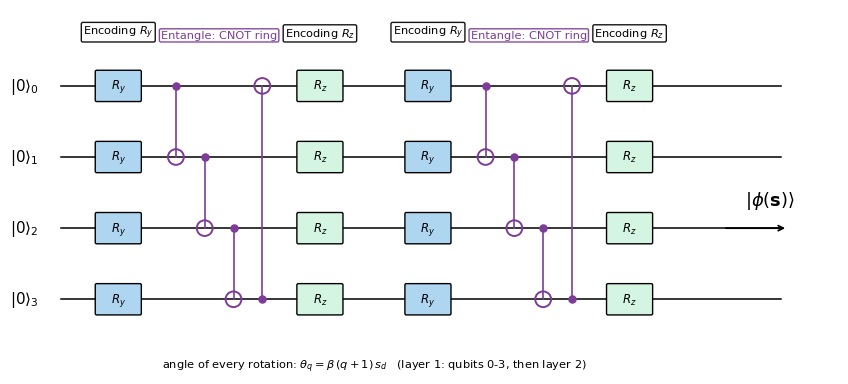

In [20]:
# Fig. 3: circuit schematic
NQ=4
fig,ax=plt.subplots(figsize=(10.5,4.6)); ax.set_xlim(0,11.3); ax.set_ylim(-0.2,NQ+0.78); ax.axis("off")

yq=lambda q:NQ-q-0.3
for q in range(NQ):
    ax.plot([0.5,10.5],[yq(q)]*2,"k",lw=1.1,zorder=1); ax.text(0.2,yq(q),fr"$|0\rangle_{{{q}}}$",va="center",ha="right",fontsize=11)
def gate(x,q,txt,col):
    ax.add_patch(FancyBboxPatch((x-.30,yq(q)-.20),.60,.40,boxstyle="round,pad=0.02",fc=col,ec="k",lw=1,zorder=5)); ax.text(x,yq(q),txt,ha="center",va="center",fontsize=8.5,zorder=6)
def cnot_draw(x,c,t,col="#7d3c98"):
    ax.plot([x,x],[min(yq(c),yq(t)),max(yq(c),yq(t))],color=col,lw=1.2,zorder=2); ax.scatter([x],[yq(c)],s=26,color=col,zorder=4)
    ax.add_patch(plt.Circle((x,yq(t)),.11,fill=False,ec=col,lw=1.4,zorder=4))
# order per layer, as in equation (11) and in the code: R_y encoding -> ring of CNOTs -> R_z encoding
for q in range(NQ): gate(1.3,q,r"$R_y$","#aed6f1"); gate(4.1,q,r"$R_z$","#d5f5e3")
for i,q in enumerate(range(NQ)): cnot_draw([2.1,2.5,2.9,3.3][i],q,(q+1)%NQ)
for q in range(NQ): gate(5.6,q,r"$R_y$","#aed6f1"); gate(8.4,q,r"$R_z$","#d5f5e3")
for i,q in enumerate(range(NQ)): cnot_draw([6.4,6.8,7.2,7.6][i],q,(q+1)%NQ)
for x,t,c in ((1.3,r"Encoding $R_y$","k"),(5.6,r"Encoding $R_y$","k"),(4.1,r"Encoding $R_z$","k"),(8.4,r"Encoding $R_z$","k")):
    ax.text(x,NQ+0.34,t,ha="center",va="bottom",fontsize=8.2,color=c,bbox=dict(boxstyle="round,pad=0.14",fc="white",ec=c,alpha=0.92),zorder=7)
for x,t,c in ((2.7,r"Entangle: CNOT ring","#7d3c98"),(7.0,r"Entangle: CNOT ring","#7d3c98")):
    ax.text(x,NQ+0.34,t,ha="center",va="bottom",fontsize=8.2,color=c,bbox=dict(boxstyle="round,pad=0.14",fc="white",ec=c,alpha=0.92),zorder=7)
ax.text(4.85,-0.12,r"angle of every rotation: $\theta_q=\beta\,(q+1)\,s_d$   (layer 1: qubits 0-3, then layer 2)",ha="center",va="top",fontsize=8.2,color="k")
ax.annotate("",xy=(10.6,NQ/2-.3),xytext=(9.7,NQ/2-.3),arrowprops=dict(arrowstyle="->",lw=1.3)); ax.text(10.0,NQ/2+.1,r"$|\phi(\mathbf{s})\rangle$",fontsize=13,va="center")
savefig_hd("fig2_circuit"); plt.show()

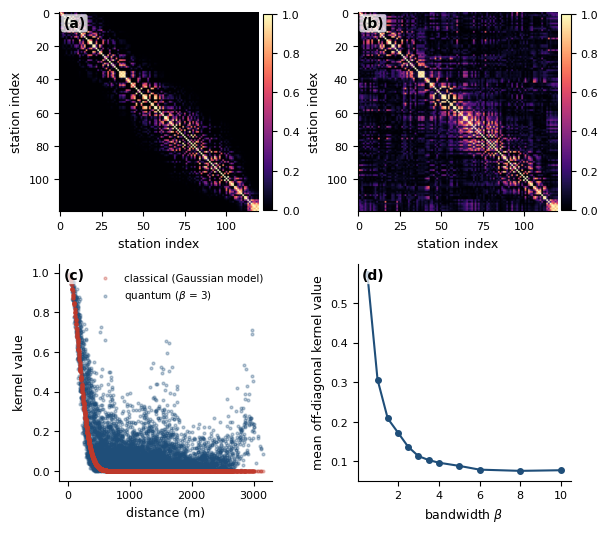

In [21]:
best0,fits0,hc0,gc0=select_variogram(P0,z0)
Kc=(fits0[best0][0][0]+fits0[best0][0][1])-vmodel(cdist(P0,P0),fits0[best0][0],best0); Kc/=Kc.max()
KQ=fidelity_kernel(*(FastEncoder(4,2,3.0).states(S0),)*2)
order=np.argsort(P0[:,0]+P0[:,1]); iu=np.triu_indices(len(P0),1); Dd=cdist(P0,P0)[iu]
betas=np.array([0.5,1,1.5,2,2.5,3,3.5,4,5,6,8,10]); offd=[fidelity_kernel(*(FastEncoder(4,2,bb).states(S0),)*2)[iu].mean() for bb in betas]
fig,axs=plt.subplots(2,2,figsize=(6.6,6.2))
im=axs[0,0].imshow(Kc[order][:,order],cmap="magma",vmin=0,vmax=1); plt.colorbar(im,ax=axs[0,0],fraction=0.046,pad=0.02); label(axs[0,0],"a",color="k")
im=axs[0,1].imshow(KQ[order][:,order],cmap="magma",vmin=0,vmax=1); plt.colorbar(im,ax=axs[0,1],fraction=0.046,pad=0.02); label(axs[0,1],"b",color="k")
for a in axs[0]: a.set_xlabel("station index"); a.set_ylabel("station index")
axs[1,0].scatter(Dd,Kc[iu],s=4,alpha=.3,color="#c0392b",label="classical (Gaussian model)",zorder=3); axs[1,0].scatter(Dd,KQ[iu],s=4,alpha=.3,color="#1f4e79",label=r"quantum ($\beta$ = 3)",zorder=2)
axs[1,0].set_xlabel("distance (m)"); axs[1,0].set_ylabel("kernel value"); axs[1,0].legend(frameon=False); label(axs[1,0],"c")
axs[1,1].plot(betas,offd,"o-",color="#1f4e79",ms=4); axs[1,1].set_xlabel(r"bandwidth $\beta$"); axs[1,1].set_ylabel("mean off-diagonal kernel value"); label(axs[1,1],"d")
plt.subplots_adjust(wspace=0.40,hspace=0.20); savefig_hd("fig3_kernels"); plt.show()

## 5. Variogram model selection
Four models are fitted by weighted least squares (Cressie weights) and the one with the lowest weighted
residual is retained. On the synthetic Gaussian field the Gaussian model is selected.

(a) Synthetic field: selected gaussian, practical range 430 m
(b) Hajjar gravity residual: selected gaussian, practical range 248 m
(c) Hajjar magnetic residual (normal scores): selected gaussian, practical range 540 m


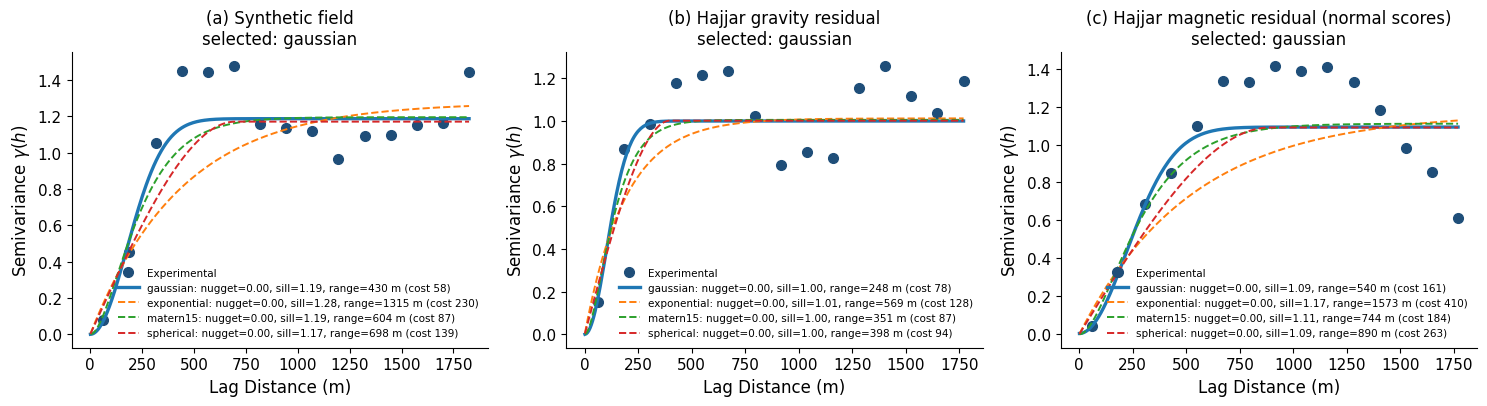

nominal practical range of the synthetic generator: sqrt(3)*ell = 520 m


In [22]:
GR=np.column_stack([grav["X"]-grav["x0"],grav["Y"]-grav["y0"]]); vg=grav["V"]; vm=mag["V"]
idx_r=sample_design(GR,120,"random",0,nx=NX,ny=NY)
zg0=(vg[idx_r]-vg[idx_r].mean())/vg[idx_r].std(); zm0=NormalScore().fit(vm[idx_r]).transform(vm[idx_r])
cases=[("(a) Synthetic field",P0,z0),("(b) Hajjar gravity residual",GR[idx_r],zg0),("(c) Hajjar magnetic residual (normal scores)",GR[idx_r],zm0)]
with plt.rc_context({"font.size":11,"axes.labelsize":12,"axes.titlesize":12,"xtick.labelsize":11,"ytick.labelsize":11,"legend.fontsize":9}):
    fig,axs=plt.subplots(1,3,figsize=(15,4.2))
    for ax,(ttl,Pd,zd) in zip(axs,cases):
        bst,fts,hc,gc=select_variogram(Pd,zd); hh=np.linspace(1,hc.max(),300)
        ax.plot(hc,gc,"o",ms=7,color="#1f4e79",label="Experimental")
        for m,(pp,cst) in fts.items():
            ax.plot(hh,vmodel(hh,pp,m),lw=2.4 if m==bst else 1.4,ls="-" if m==bst else "--",
                    label=f"{m}: nugget={pp[0]:.2f}, sill={pp[1]:.2f}, range={pp[2]:.0f} m (cost {cst:.0f})")
        ax.set_xlabel("Lag Distance (m)"); ax.set_ylabel(r"Semivariance $\gamma(h)$")
        ax.set_title(f"{ttl}\nselected: {bst}"); ax.legend(frameon=False,loc="lower right",fontsize=7.5)
        print(f"{ttl}: selected {bst}, practical range {fts[bst][0][2]:.0f} m")
    plt.tight_layout(); savefig_hd("fig4_variograms"); plt.show()
print("nominal practical range of the synthetic generator: sqrt(3)*ell =",round(np.sqrt(3)*ELL),"m")
def selection_frequency(runs):
    import collections; c=collections.Counter(); rg=[]
    for r in runs:
        for i in r["OK"]["infos"]: c[i["model"]]+=1; rg.append(i["params"][2])
    return dict(c), float(np.median(rg))


## 6. Evaluation protocol
Outer 10-fold cross-validation on the sampled stations; every hyperparameter is selected inside the training
fold (inner 3-fold or marginal likelihood). Point metrics: RMSE, MAE, R^2. Probabilistic metrics: 95%
prediction-interval coverage, CRPS and negative log predictive density (Gneiting and Raftery, 2007). Each
experiment is repeated over seeds (field realisation, stations and noise all change with the seed), and
paired Wilcoxon signed-rank tests compare methods across seeds.

In [23]:
import pickle, os
RECOMPUTE=False   # set True to recompute every experiment from scratch (about 25 min on a laptop)
def cached(name,fn):
    path=f"cache/{name}.pkl"
    if not RECOMPUTE and os.path.exists(path): return pickle.load(open(path,"rb"))
    r=fn(); os.makedirs("cache",exist_ok=True); pickle.dump(r,open(path,"wb")); return r
def run_repeats(make_case,seeds,methods=METHODS,outer=10,tag=None,**kw):
    runs=[]
    for s in seeds:
        def fn():
            P,z=make_case(s); return nested_cv(P,z,L0,methods=methods,outer=outer,seed=s,**kw)
        r=cached(f"{tag}_seed{s}",fn) if tag else fn(); runs.append(r)
        print(f"  seed {s}: "+"  ".join(f"{m} R2={r[m]['r2']:.3f}" for m in methods if m in r))
    return runs
def print_table(runs,methods=METHODS,title=""):
    tab=summarize(runs,methods); print(title)
    print(f"{'method':10s} {'RMSE':>13} {'MAE':>13} {'R2':>13} {'cov95':>11} {'CRPS':>13} {'NLPD':>12} {'time(s)':>8}")
    for m in methods:
        t=tab[m]; f=lambda k,d=3: f"{t[k][0]:.{d}f}+/-{t[k][1]:.{d}f}"
        print(f"{m:10s} {f('rmse'):>13} {f('mae'):>13} {f('r2'):>13} {f('cov95',2):>11} {f('crps'):>13} {f('nlpd',2):>12} {t['time'][0]:8.1f}")
    return tab
def print_tests(runs,pairs):
    for a,b in pairs:
        p,diff=paired_test(runs,a,b); print(f"  {a} vs {b}: mean RMSE difference = {diff:+.3f}, Wilcoxon p = {p:.3f}")

## 7. Main benchmark on the synthetic field (6 realisations, 120 stations)

In [24]:
t0=time.time()
runs_syn=run_repeats(lambda s: synthetic_case(s)[2:],range(SEEDS_MAIN),tag="syn")
tab_syn=print_table(runs_syn,title=f"\nSynthetic field, n=120, {SEEDS_MAIN} realisations, 10-fold nested CV (mean +/- SD):")
print("variogram model selected across the 60 training folds (synthetic):",selection_frequency(runs_syn))
print_tests(runs_syn,[("OK","GP-Matern"),("Quantum","OK"),("Quantum","GP-Matern"),("Hybrid","GP-Matern"),("Hybrid","Quantum")])
print("chosen quantum (nq,L,beta):",sorted(set((i['nq'],i['reps'],i['beta']) for r in runs_syn for i in r['Quantum']['infos'])))
print("estimated GP noise variance (quantum):",np.round(np.median([i['sig_n'] for r in runs_syn for i in r['Quantum']['infos']]),4),"| observation noise variance = 0.0064")
print(f"section time {time.time()-t0:.0f}s")

  seed 0: OK R2=0.932  GP-RBF R2=0.947  GP-Matern R2=0.930  GP-ARD R2=0.947  RF R2=0.687  Quantum R2=0.894  Hybrid R2=0.924
  seed 1: OK R2=0.940  GP-RBF R2=0.958  GP-Matern R2=0.954  GP-ARD R2=0.953  RF R2=0.753  Quantum R2=0.948  Hybrid R2=0.949
  seed 2: OK R2=0.919  GP-RBF R2=0.927  GP-Matern R2=0.896  GP-ARD R2=0.923  RF R2=0.737  Quantum R2=0.915  Hybrid R2=0.911
  seed 3: OK R2=0.931  GP-RBF R2=0.947  GP-Matern R2=0.945  GP-ARD R2=0.948  RF R2=0.803  Quantum R2=0.934  Hybrid R2=0.937
  seed 4: OK R2=0.912  GP-RBF R2=0.924  GP-Matern R2=0.923  GP-ARD R2=0.926  RF R2=0.682  Quantum R2=0.877  Hybrid R2=0.901
  seed 5: OK R2=0.883  GP-RBF R2=0.940  GP-Matern R2=0.920  GP-ARD R2=0.939  RF R2=0.591  Quantum R2=0.877  Hybrid R2=0.913

Synthetic field, n=120, 6 realisations, 10-fold nested CV (mean +/- SD):
method              RMSE           MAE            R2       cov95          CRPS         NLPD  time(s)
OK         0.282+/-0.015 0.195+/-0.018 0.919+/-0.018 1.00+/-0.00 0.151+/-0.013  0

### 7b. Denser sampling: 240 stations

In [26]:
runs_syn240=run_repeats(lambda s: synthetic_case(s,n=240)[2:],range(SEEDS_MAIN),tag="syn240")
tab_syn240=print_table(runs_syn240,title=f"\nSynthetic field, n=240, {SEEDS_MAIN} realisations, 10-fold nested CV (mean +/- SD):")
print_tests(runs_syn240,[("Quantum","OK"),("Quantum","GP-RBF"),("Hybrid","OK"),("Hybrid","GP-RBF")])
print("selected register (nq,L) frequencies, n=120:",{k:sum(1 for r in runs_syn for i in r['Quantum']['infos'] if (i['nq'],i['reps'])==k) for k in [(4,2),(4,3),(5,2),(5,3),(6,2),(6,3)]})
print("hybrid alpha frequencies, n=120:",{a:sum(1 for r in runs_syn for i in r['Hybrid']['infos'] if i['alpha']==a) for a in (0.0,0.25,0.5,0.75,1.0)})


  seed 0: OK R2=0.967  GP-RBF R2=0.981  GP-Matern R2=0.978  GP-ARD R2=0.981  RF R2=0.873  Quantum R2=0.971  Hybrid R2=0.975
  seed 1: OK R2=0.969  GP-RBF R2=0.983  GP-Matern R2=0.970  GP-ARD R2=0.982  RF R2=0.853  Quantum R2=0.973  Hybrid R2=0.974
  seed 2: OK R2=0.979  GP-RBF R2=0.980  GP-Matern R2=0.979  GP-ARD R2=0.980  RF R2=0.892  Quantum R2=0.970  Hybrid R2=0.974
  seed 3: OK R2=0.975  GP-RBF R2=0.982  GP-Matern R2=0.979  GP-ARD R2=0.983  RF R2=0.863  Quantum R2=0.979  Hybrid R2=0.980
  seed 4: OK R2=0.961  GP-RBF R2=0.974  GP-Matern R2=0.966  GP-ARD R2=0.972  RF R2=0.756  Quantum R2=0.953  Hybrid R2=0.965
  seed 5: OK R2=0.980  GP-RBF R2=0.979  GP-Matern R2=0.974  GP-ARD R2=0.978  RF R2=0.831  Quantum R2=0.951  Hybrid R2=0.962

Synthetic field, n=240, 6 realisations, 10-fold nested CV (mean +/- SD):
method              RMSE           MAE            R2       cov95          CRPS         NLPD  time(s)
OK         0.165+/-0.018 0.120+/-0.012 0.972+/-0.007 1.00+/-0.00 0.100+/-0.009 -0

## 8. Uncertainty calibration
Predicted standard deviation against actual absolute error, pooled over folds and realisations. A calibrated model has RMSE close to the mean predicted SD within each bin.

## 9. Sensitivity analysis (synthetic field)
Number of stations, correlation length, noise level and sampling design; 3 realisations each, 5-fold outer CV. The random forest is omitted from the sweeps for run time.

In [28]:
SENS_METHODS=["OK","GP-Matern","Quantum","Hybrid"]
def sweep(param,values,base=dict(n=120,ell=ELL,noise=0.08,design="random")):
    out={}
    for v in values:
        kw=dict(base); kw[param]=v
        def fn():
            runs=run_repeats(lambda s: synthetic_case(s,**kw)[2:],range(SEEDS_SENS),methods=SENS_METHODS,outer=5)
            return summarize(runs,SENS_METHODS)
        out[v]=cached(f"sens_{param}_{v}",fn); print(f" -> {param}={v}: "+" ".join(f"{m} R2={out[v][m]['r2'][0]:.3f}" for m in SENS_METHODS))
    return out
t0=time.time()
sens={}
sens["n"]=sweep("n",[60,120,240,360])
sens["ell"]=sweep("ell",[150,300,600])
sens["noise"]=sweep("noise",[0.02,0.08,0.2,0.4])
sens["design"]=sweep("design",["random","clustered","lines"])
print(f"sensitivity time {time.time()-t0:.0f}s")

 -> n=60: OK R2=0.672 GP-Matern R2=0.705 Quantum R2=0.622 Hybrid R2=0.647
 -> n=120: OK R2=0.918 GP-Matern R2=0.918 Quantum R2=0.912 Hybrid R2=0.926
 -> n=240: OK R2=0.969 GP-Matern R2=0.971 Quantum R2=0.969 Hybrid R2=0.970
 -> n=360: OK R2=0.978 GP-Matern R2=0.985 Quantum R2=0.984 Hybrid R2=0.985
 -> ell=150: OK R2=0.483 GP-Matern R2=0.485 Quantum R2=0.450 Hybrid R2=0.457
 -> ell=300: OK R2=0.918 GP-Matern R2=0.918 Quantum R2=0.912 Hybrid R2=0.926
 -> ell=600: OK R2=0.986 GP-Matern R2=0.981 Quantum R2=0.976 Hybrid R2=0.985
 -> noise=0.02: OK R2=0.927 GP-Matern R2=0.929 Quantum R2=0.916 Hybrid R2=0.933
 -> noise=0.08: OK R2=0.918 GP-Matern R2=0.918 Quantum R2=0.912 Hybrid R2=0.926
 -> noise=0.2: OK R2=0.865 GP-Matern R2=0.876 Quantum R2=0.827 Hybrid R2=0.872
 -> noise=0.4: OK R2=0.754 GP-Matern R2=0.764 Quantum R2=0.718 Hybrid R2=0.748
 -> design=random: OK R2=0.918 GP-Matern R2=0.918 Quantum R2=0.912 Hybrid R2=0.926
 -> design=clustered: OK R2=0.947 GP-Matern R2=0.958 Quantum R2=0.939

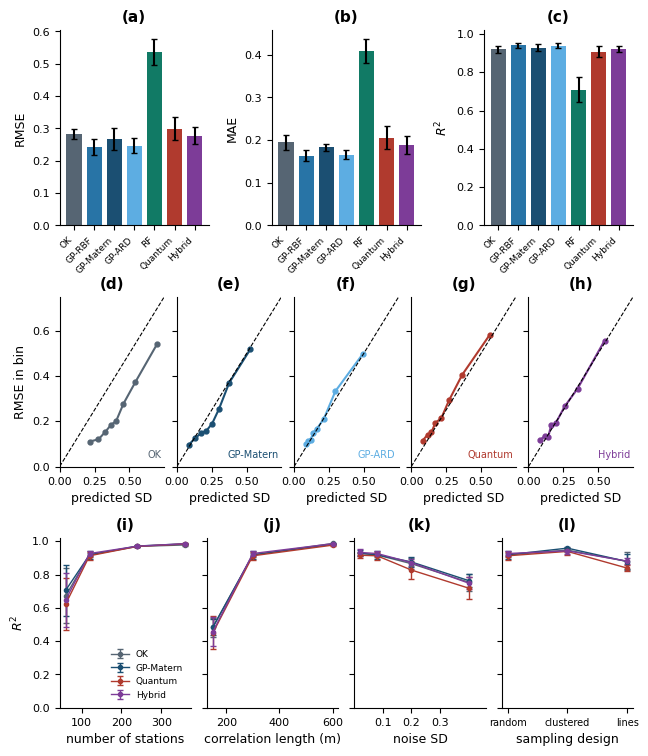

In [29]:
def bar_row(axs,tab,methods,labels,center_labels=False):
    for k,(ax,met,lab,l) in enumerate(zip(axs,["rmse","mae","r2"],["RMSE","MAE",r"$R^2$"],labels)):
        mu=[tab[m][met][0] for m in methods]; sd=[tab[m][met][1] for m in methods]
        ax.bar(range(len(methods)),mu,yerr=sd,capsize=2,color=[cols[m] for m in methods],width=0.75)
        ax.set_xticks(range(len(methods))); ax.set_xticklabels(methods,rotation=45,ha="right",fontsize=6.5); ax.set_ylabel(lab)
        if center_labels: ax.set_title(f"({l})",fontweight="bold",pad=6)
        else: label(ax,l,inside=False)
        if met=="r2": ax.set_ylim(0,1.02)
def calib_row(axs,runs,methods,labels,lim=0.75,center_labels=False):
    for k,(ax,m,l) in enumerate(zip(axs,methods,labels)):
        s=np.concatenate([r[m]['ys'] for r in runs]); e=np.abs(np.concatenate([r[m]['yt']-r[m]['yp'] for r in runs]))
        q=np.quantile(s,np.linspace(0,1,9)); xs_,ys_=[],[]
        for lo,hi in zip(q[:-1],q[1:]):
            kk=(s>=lo)&(s<=hi)
            if kk.sum()>5: xs_.append(s[kk].mean()); ys_.append(np.sqrt(np.mean(e[kk]**2)))
        ax.plot(xs_,ys_,"o-",color=cols[m],ms=3.5); ax.plot([0,lim],[0,lim],"k--",lw=0.8); ax.set_xlim(0,lim); ax.set_ylim(0,lim); ax.set_xticks(np.arange(0,lim-0.1,0.25))
        ax.set_xlabel("predicted SD"); ax.set_ylabel("RMSE in bin" if k==0 else "")
        if k>0: ax.set_yticklabels([])
        ax.text(0.97,0.05,m,transform=ax.transAxes,ha="right",fontsize=7,color=cols[m])
        if center_labels: ax.set_title(f"({l})",fontweight="bold",pad=6)
        else: label(ax,l,inside=False)
fig=plt.figure(figsize=(7.4,8.8)); outer=fig.add_gridspec(3,1,hspace=0.40,height_ratios=[1.15,1,1])
g0=outer[0].subgridspec(1,3,wspace=0.42); ax1=[fig.add_subplot(g0[0,i]) for i in range(3)]; bar_row(ax1,tab_syn,METHODS,"abc",center_labels=True)
g1=outer[1].subgridspec(1,5,wspace=0.12); ax2=[fig.add_subplot(g1[0,i]) for i in range(5)]; calib_row(ax2,runs_syn,["OK","GP-Matern","GP-ARD","Quantum","Hybrid"],"defgh",center_labels=True)
g2=outer[2].subgridspec(1,4,wspace=0.12); ax3=[fig.add_subplot(g2[0,i]) for i in range(4)]
for k,(ax,(param,lab),l) in enumerate(zip(ax3,[("n","number of stations"),("ell","correlation length (m)"),("noise","noise SD"),("design","sampling design")],"ijkl")):
    d=sens[param]; xs_=list(d.keys())
    for m in SENS_METHODS:
        mu=[d[v][m]["r2"][0] for v in xs_]; sd=[d[v][m]["r2"][1] for v in xs_]; xx=range(len(xs_)) if param=="design" else xs_
        ax.errorbar(xx,mu,yerr=sd,marker="o",ms=3,capsize=2,label=m,color=cols[m],lw=1)
    if param=="design": ax.set_xticks(range(len(xs_))); ax.set_xticklabels(["random","clustered","lines"],fontsize=7)
    if param=="noise": ax.set_xlim(0,0.46); ax.set_xticks([0.1,0.2,0.3])
    if param=="ell": ax.set_xticks([200,400,600])
    ax.set_xlabel(lab); ax.set_ylim(0,1.02); ax.set_ylabel(r"$R^2$" if k==0 else "")
    if k>0: ax.set_yticklabels([])
    ax.set_title(f"({l})",fontweight="bold",pad=6)
ax3[0].legend(frameon=False,fontsize=6.5,loc="lower right")
savefig_hd("fig5_synthetic_benchmark"); plt.show()

## 10. Ablation of the quantum feature map
Entanglement on/off, number of qubits, number of re-uploading layers; the bandwidth beta is re-tuned by inner CV for every configuration, because its optimum depends on the register size and depth.

configuration                  R2 mean+/-SD           RMSE typical beta
nq=4, L=2, ent=on             0.858+/-0.030   0.389+/-0.032   2.0
nq=4, L=2, ent=off            0.809+/-0.035   0.453+/-0.030   1.5
nq=2, L=2, ent=on             0.355+/-0.092   0.838+/-0.078   3.0
nq=3, L=2, ent=on             0.627+/-0.020   0.638+/-0.006   2.5
nq=5, L=2, ent=on             0.918+/-0.022   0.294+/-0.035   2.0
nq=6, L=2, ent=on             0.909+/-0.003   0.315+/-0.004   1.5
nq=4, L=1, ent=on             0.837+/-0.044   0.417+/-0.050   2.5
nq=4, L=3, ent=on             0.889+/-0.014   0.347+/-0.013   2.5
ablation time 0s


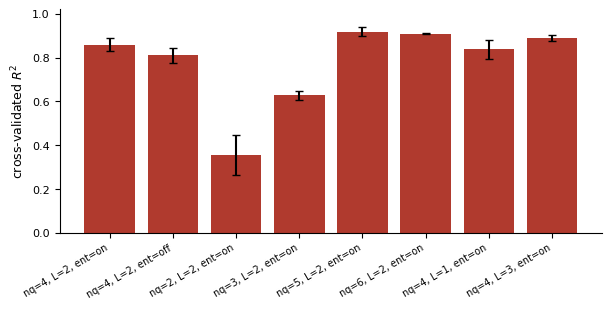

In [30]:
t0=time.time()
cfgs=[dict(nq=4,reps=2,entangle=True),dict(nq=4,reps=2,entangle=False),
      dict(nq=2,reps=2,entangle=True),dict(nq=3,reps=2,entangle=True),dict(nq=5,reps=2,entangle=True),dict(nq=6,reps=2,entangle=True),
      dict(nq=4,reps=1,entangle=True),dict(nq=4,reps=3,entangle=True)]
abl={}
for s in range(SEEDS_ABL):
    def fn():
        _,_,P,z=synthetic_case(s); return ablation_quantum(P,z,L0,cfgs,outer=5,seed=s)
    a=cached(f"abl_seed{s}",fn)
    for k,v in a.items(): abl.setdefault(k,[]).append(v)
print(f"{'configuration':26s} {'R2 mean+/-SD':>16} {'RMSE':>14} typical beta")
for k,v in abl.items():
    r2=[x['r2'] for x in v]; rm=[x['rmse'] for x in v]; bt=np.median([b for x in v for b in x['betas']])
    print(f"{k:26s} {np.mean(r2):8.3f}+/-{np.std(r2):.3f} {np.mean(rm):7.3f}+/-{np.std(rm):.3f}   {bt:.1f}")
print(f"ablation time {time.time()-t0:.0f}s")
fig,ax=plt.subplots(figsize=(7.0,2.9)); labs=list(abl.keys())
ax.bar(range(len(labs)),[np.mean([x['r2'] for x in abl[k]]) for k in labs],yerr=[np.std([x['r2'] for x in abl[k]]) for k in labs],capsize=3,color="#b03a2e")
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs,rotation=30,ha="right",fontsize=7); ax.set_ylabel(r"cross-validated $R^2$"); ax.set_ylim(0,1.02)
savefig_hd("fig6_ablation"); plt.show()

## 11. Anisotropic and non-stationary fields, with a location-dependence diagnostic
The diagnostic eta^2 is the fraction of the kernel-value variance at fixed distance that is explained by *where* the pair sits (4 x 4 cells). A stationary kernel has eta^2 near zero.

  seed 0: OK R2=0.694  GP-RBF R2=0.744  GP-Matern R2=0.709  GP-ARD R2=0.798  RF R2=0.609  Quantum R2=0.805  Hybrid R2=0.797
  seed 1: OK R2=0.551  GP-RBF R2=0.624  GP-Matern R2=0.607  GP-ARD R2=0.663  RF R2=0.475  Quantum R2=0.597  Hybrid R2=0.609
  seed 2: OK R2=0.815  GP-RBF R2=0.838  GP-Matern R2=0.834  GP-ARD R2=0.829  RF R2=0.668  Quantum R2=0.805  Hybrid R2=0.799
  seed 3: OK R2=0.773  GP-RBF R2=0.757  GP-Matern R2=0.788  GP-ARD R2=0.782  RF R2=0.686  Quantum R2=0.791  Hybrid R2=0.769

Anisotropic field (600 m / 150 m, 30 deg), 4 realisations:
method              RMSE           MAE            R2       cov95          CRPS         NLPD  time(s)
OK         0.536+/-0.085 0.381+/-0.060 0.708+/-0.100 0.96+/-0.02 0.280+/-0.045  0.68+/-0.18      0.3
GP-RBF     0.507+/-0.069 0.347+/-0.048 0.741+/-0.076 0.91+/-0.01 0.252+/-0.039  0.67+/-0.19      1.1
GP-Matern  0.513+/-0.079 0.350+/-0.051 0.735+/-0.086 0.93+/-0.02 0.255+/-0.043  0.49+/-0.25      1.3
GP-ARD     0.481+/-0.053 0.330+/-0.036 0

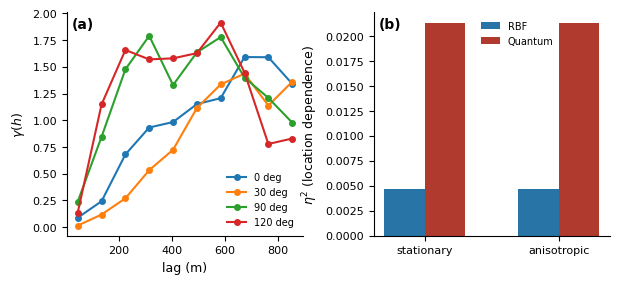

eta^2: {'stationary': {'RBF': 0.005, 'Quantum': 0.021}, 'anisotropic': {'RBF': 0.005, 'Quantum': 0.021}}
section time 1s


In [31]:
t0=time.time()
runs_aniso=run_repeats(lambda s: synthetic_case(s,anis=(600,150,30))[2:],range(SEEDS_FIELD),tag="aniso")
tab_aniso=print_table(runs_aniso,title=f"\nAnisotropic field (600 m / 150 m, 30 deg), {SEEDS_FIELD} realisations:")
print_tests(runs_aniso,[("Quantum","GP-ARD"),("Quantum","GP-Matern"),("Hybrid","GP-ARD")])
runs_nonst=run_repeats(lambda s: synthetic_case(s,nonstat=(150,450))[2:],range(SEEDS_FIELD),tag="nonst")
tab_nonst=print_table(runs_nonst,title=f"\nNon-stationary field (west 150 m / east 450 m), {SEEDS_FIELD} realisations:")
print_tests(runs_nonst,[("Quantum","GP-Matern"),("Hybrid","GP-Matern")])
# directional variograms on the anisotropic field, and eta^2 diagnostics
_,_,Pa,za=synthetic_case(7,anis=(600,150,30))
fig,axs=plt.subplots(1,2,figsize=(7.0,2.9))
for ang in (0,30,90,120):
    h,g=directional_variogram(Pa,za,ang,nlags=10,hmax=900); axs[0].plot(h,g,"o-",ms=4,label=f"{ang} deg")
axs[0].set_xlabel("lag (m)"); axs[0].set_ylabel(r"$\gamma(h)$"); axs[0].legend(frameon=False,fontsize=7); label(axs[0],"a")
etas={}
for lab,(Pd,_) in (("stationary",(P0,None)),("anisotropic",(Pa,None))):
    Sd=Pd/L0; etas[lab]=dict(RBF=kernel_location_dependence(Pd,rbf_corr(Sd,Sd,0.07)),Quantum=kernel_location_dependence(Pd,fidelity_kernel(*(FastEncoder(4,2,3.0).states(Sd),)*2)))
x=np.arange(2); axs[1].bar(x-0.15,[etas[l]["RBF"] for l in etas],0.3,label="RBF",color="#2874a6"); axs[1].bar(x+0.15,[etas[l]["Quantum"] for l in etas],0.3,label="Quantum",color="#b03a2e")
axs[1].set_xticks(x); axs[1].set_xticklabels(list(etas)); axs[1].set_ylabel(r"$\eta^2$ (location dependence)"); axs[1].legend(frameon=False,fontsize=7,loc="upper right",bbox_to_anchor=(0.80,1.0)); label(axs[1],"b")
plt.subplots_adjust(wspace=0.3); savefig_hd("fig7_anisotropy"); plt.show()
print("eta^2:",{k:{kk:round(vv,3) for kk,vv in v.items()} for k,v in etas.items()}); print(f"section time {time.time()-t0:.0f}s")

## 12. Real data: Hajjar gravity and magnetic residuals
For each dataset, 120 stations are drawn from the 18,060 survey nodes (a different subset per seed) and the
methods are compared by nested 10-fold CV on the stations. The strongly skewed magnetic residual (skewness
about 4) is modelled after a normal-score transform fitted on the training stations only; metrics are reported
in transformed units and, for the RMSE, back-transformed to nT. Full-grid maps and predictive standard
deviations are then produced for one subset and compared with the dense survey.

  seed 0: OK R2=0.667  GP-RBF R2=0.724  GP-Matern R2=0.735  GP-ARD R2=0.740  RF R2=0.544  Quantum R2=0.761  Hybrid R2=0.779
  seed 1: OK R2=0.693  GP-RBF R2=0.677  GP-Matern R2=0.710  GP-ARD R2=0.668  RF R2=0.535  Quantum R2=0.610  Hybrid R2=0.636
  seed 2: OK R2=0.760  GP-RBF R2=0.791  GP-Matern R2=0.754  GP-ARD R2=0.777  RF R2=0.502  Quantum R2=0.718  Hybrid R2=0.698
  seed 3: OK R2=0.771  GP-RBF R2=0.760  GP-Matern R2=0.781  GP-ARD R2=0.772  RF R2=0.592  Quantum R2=0.768  Hybrid R2=0.786
  seed 4: OK R2=0.709  GP-RBF R2=0.809  GP-Matern R2=0.812  GP-ARD R2=0.827  RF R2=0.574  Quantum R2=0.760  Hybrid R2=0.797
  seed 5: OK R2=0.600  GP-RBF R2=0.675  GP-Matern R2=0.711  GP-ARD R2=0.691  RF R2=0.494  Quantum R2=0.688  Hybrid R2=0.708

Hajjar GRAVITY residual, n=120, 6 station subsets (standardised units):
method              RMSE           MAE            R2       cov95          CRPS         NLPD  time(s)
OK         0.545+/-0.052 0.393+/-0.053 0.700+/-0.057 0.99+/-0.01 0.288+/-0.034  0.

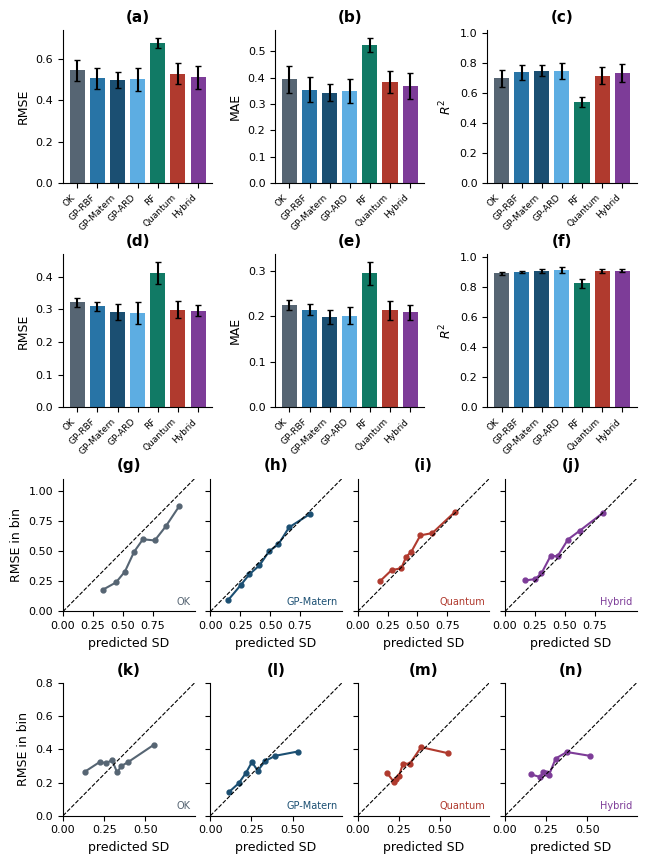

In [32]:
t0=time.time()
GR=np.column_stack([grav["X"]-grav["x0"],grav["Y"]-grav["y0"]]); vg=grav["V"]; vm=mag["V"]
def grav_case(s):
    idx=sample_design(GR,120,"random",s,nx=NX,ny=NY); z=(vg[idx]-vg[idx].mean())/vg[idx].std(); return GR[idx],z
def mag_case(s):
    idx=sample_design(GR,120,"random",s,nx=NX,ny=NY); ns=NormalScore().fit(vm[idx]); return GR[idx],ns.transform(vm[idx])
runs_grav=run_repeats(grav_case,range(SEEDS_MAIN),tag="grav"); tab_grav=print_table(runs_grav,title=f"\nHajjar GRAVITY residual, n=120, {SEEDS_MAIN} station subsets (standardised units):")
print_tests(runs_grav,[("Quantum","GP-Matern"),("Hybrid","GP-Matern"),("Hybrid","OK")])
runs_mag=run_repeats(mag_case,range(SEEDS_MAIN),tag="mag"); tab_mag=print_table(runs_mag,title=f"\nHajjar MAGNETIC residual, n=120, {SEEDS_MAIN} station subsets (normal-score units):")
print_tests(runs_mag,[("Hybrid","GP-Matern"),("Hybrid","OK"),("Quantum","GP-RBF"),("Hybrid","Quantum")])
print("variogram model selected across training folds: gravity",selection_frequency(runs_grav),"| magnetic",selection_frequency(runs_mag))
print("gravity: register choices",sorted(set((i['nq'],i['reps']) for r in runs_grav for i in r['Quantum']['infos'])),"| alpha",sorted(set(i['alpha'] for r in runs_grav for i in r['Hybrid']['infos'])))
print("magnetic: register choices",sorted(set((i['nq'],i['reps']) for r in runs_mag for i in r['Quantum']['infos'])),"| alpha",sorted(set(i['alpha'] for r in runs_mag for i in r['Hybrid']['infos'])))
print(f"real-data time {time.time()-t0:.0f}s")
fig=plt.figure(figsize=(7.4,10.2)); outer=fig.add_gridspec(4,1,hspace=0.50,height_ratios=[1.15,1.15,1,1])
g0=outer[0].subgridspec(1,3,wspace=0.42); r1=[fig.add_subplot(g0[0,i]) for i in range(3)]; bar_row(r1,tab_grav,METHODS,"abc",center_labels=True)
g1=outer[1].subgridspec(1,3,wspace=0.42); r2=[fig.add_subplot(g1[0,i]) for i in range(3)]; bar_row(r2,tab_mag,METHODS,"def",center_labels=True)
g2=outer[2].subgridspec(1,4,wspace=0.12); r3=[fig.add_subplot(g2[0,i]) for i in range(4)]; calib_row(r3,runs_grav,["OK","GP-Matern","Quantum","Hybrid"],"ghij",lim=1.1,center_labels=True)
g3=outer[3].subgridspec(1,4,wspace=0.12); r4=[fig.add_subplot(g3[0,i]) for i in range(4)]; calib_row(r4,runs_mag,["OK","GP-Matern","Quantum","Hybrid"],"klmn",lim=0.8,center_labels=True)
savefig_hd("fig8_real_benchmark"); plt.show()

gravity full-grid, OK: R2=0.723, RMSE=79.7 microGal
gravity full-grid, GP-Matern: R2=0.788, RMSE=69.7 microGal
gravity full-grid, Quantum: R2=0.720, RMSE=80.2 microGal
gravity full-grid, Hybrid: R2=0.750, RMSE=75.8 microGal
(dense-survey std = 0.151 mGal)


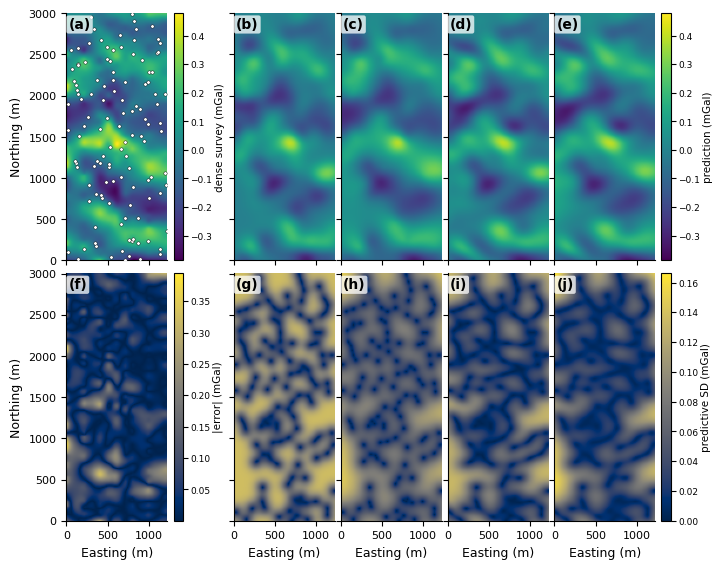

In [33]:
def full_maps(case,seed):
    P,z=case(seed); out={}
    for m in ["OK","GP-Matern","Quantum","Hybrid"]:
        mu,sd,_=run_method(m,P,z,GR,L0,seed=seed); out[m]=(mu,sd)
    return P,z,out
def map_grid():
    fig=plt.figure(figsize=(8.4,6.6)); gs_=fig.add_gridspec(2,7,width_ratios=[1,0.55,1,1,1,1,0.55],wspace=0.05,hspace=0.05)
    top=[fig.add_subplot(gs_[0,j]) for j in (0,2,3,4,5)]; bot=[fig.add_subplot(gs_[1,j]) for j in (0,2,3,4,5)]
    cbar=lambda r,c: (lambda col: (col.axis("off"), col.inset_axes([0.02,0.0,0.17,1.0]))[1])(fig.add_subplot(gs_[r,c]))
    cax=dict(a=cbar(0,1),top=cbar(0,6),f=cbar(1,1),bot=cbar(1,6))     # four colorbar axes of identical height
    return fig,top,bot,cax
def colorbar_on(fig,im,cax,lab):
    c=fig.colorbar(im,cax=cax); c.set_label(lab,fontsize=7.5,labelpad=2); c.ax.tick_params(labelsize=6.5,pad=1.5); return c
P_g,z_g,maps_g=full_maps(grav_case,0)
ig=sample_design(GR,120,"random",0,nx=NX,ny=NY); mg,sg=vg[ig].mean(),vg[ig].std()      # back to mGal with the training-station statistics
maps_g={m:(maps_g[m][0]*sg+mg, maps_g[m][1]*sg) for m in maps_g}                        # predictions and predictive SD in mGal
vmin,vmax=vg.min(),vg.max(); sdmax=max(maps_g[m][1].max() for m in maps_g)
fig,top,bot,cax=map_grid()
im=map_panel(top[0],vg,vmin=vmin,vmax=vmax,pts=P_g,xl=False,cb=False); label(top[0],"a")
for j,m in enumerate(["OK","GP-Matern","Quantum","Hybrid"]):
    mu,sd=maps_g[m]; r2=1-np.sum((mu-vg)**2)/np.sum((vg-vg.mean())**2); rmse=np.sqrt(np.mean((mu-vg)**2))
    imp=map_panel(top[j+1],mu,vmin=vmin,vmax=vmax,xl=False,yl=False,cb=False); label(top[j+1],"bcde"[j])
    ims=map_panel(bot[j+1],sd,cmap="cividis",vmin=0,vmax=sdmax,yl=False,cb=False); label(bot[j+1],"ghij"[j])
    print(f"gravity full-grid, {m}: R2={r2:.3f}, RMSE={rmse*1000:.1f} microGal")
ime=map_panel(bot[0],np.abs(maps_g["Hybrid"][0]-vg),cmap="cividis",cb=False); label(bot[0],"f")
colorbar_on(fig,im,cax["a"],"dense survey (mGal)"); colorbar_on(fig,imp,cax["top"],"prediction (mGal)")
colorbar_on(fig,ime,cax["f"],"|error| (mGal)"); colorbar_on(fig,ims,cax["bot"],"predictive SD (mGal)")
print("(dense-survey std = %.3f mGal)"%vg.std())
savefig_hd("fig9_maps_gravity"); plt.show()

magnetic full-grid RMSE, OK: 36.3 nT | median predictive SD 5.2 nT
magnetic full-grid RMSE, GP-Matern: 30.5 nT | median predictive SD 7.0 nT
magnetic full-grid RMSE, Quantum: 44.5 nT | median predictive SD 8.4 nT
magnetic full-grid RMSE, Hybrid: 32.3 nT | median predictive SD 8.3 nT


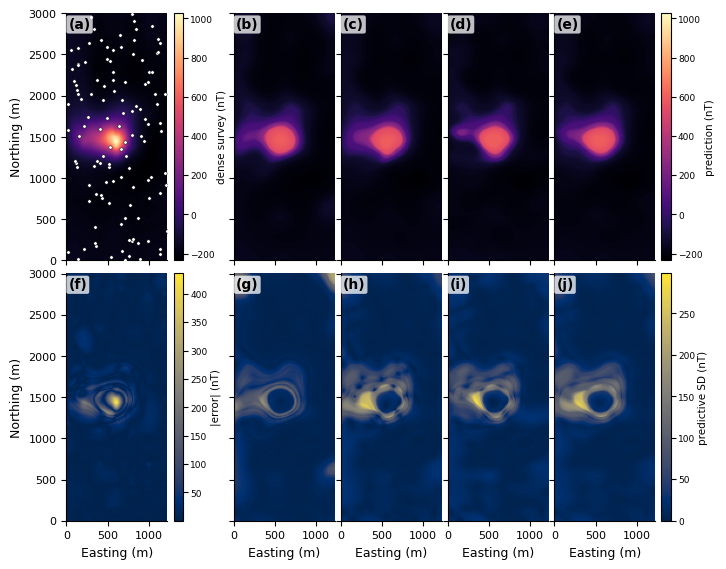

(dense-survey std = 151 nT)


In [34]:
idx0m=sample_design(GR,120,"random",0,nx=NX,ny=NY); ns0=NormalScore().fit(vm[idx0m])
P_m,z_m,maps_m=full_maps(mag_case,0)
# back-transform to nT: mean through the inverse normal-score transform; SD by the delta method through the same transform
maps_m={m:(ns0.inverse(maps_m[m][0]), 0.5*(ns0.inverse(maps_m[m][0]+maps_m[m][1])-ns0.inverse(maps_m[m][0]-maps_m[m][1]))) for m in maps_m}
vmin,vmax=vm.min(),vm.max(); sdmax=max(maps_m[m][1].max() for m in maps_m)
fig,top,bot,cax=map_grid()
im=map_panel(top[0],vm,cmap="magma",vmin=vmin,vmax=vmax,pts=P_m,xl=False,cb=False); label(top[0],"a")
for j,m in enumerate(["OK","GP-Matern","Quantum","Hybrid"]):
    mu,sd=maps_m[m]; rmse_nT=np.sqrt(np.mean((mu-vm)**2))
    imp=map_panel(top[j+1],mu,cmap="magma",vmin=vmin,vmax=vmax,xl=False,yl=False,cb=False); label(top[j+1],"bcde"[j])
    ims=map_panel(bot[j+1],sd,cmap="cividis",vmin=0,vmax=sdmax,yl=False,cb=False); label(bot[j+1],"ghij"[j])
    print(f"magnetic full-grid RMSE, {m}: {rmse_nT:.1f} nT | median predictive SD {np.median(sd):.1f} nT")
ime=map_panel(bot[0],np.abs(maps_m["Hybrid"][0]-vm),cmap="cividis",cb=False); label(bot[0],"f")
colorbar_on(fig,im,cax["a"],"dense survey (nT)"); colorbar_on(fig,imp,cax["top"],"prediction (nT)")
colorbar_on(fig,ime,cax["f"],"|error| (nT)"); colorbar_on(fig,ims,cax["bot"],"predictive SD (nT)")
savefig_hd("fig10_maps_magnetic"); plt.show()
print("(dense-survey std = %.0f nT)"%vm.std())

## 13. Computational cost
Wall-clock time per nested-CV run (all folds, including hyperparameter selection), from the synthetic benchmark; and the cost of encoding the full grid.

In [35]:
print(f"{'method':10s} {'mean time per nested-CV run (s)':>34}")
for m in METHODS: print(f"{m:10s} {tab_syn[m]['time'][0]:34.1f}")
t=time.time(); _=FastEncoder().states(GRID/L0); print(f"\nQuantum encoding of {len(GRID)} grid nodes (4 qubits, 2 layers): {time.time()-t:.2f} s")
n=len(P0); print(f"GP solve with n={n} training points: cubic cost O(n^3) unchanged by the quantum kernel (computed classically here)")

method        mean time per nested-CV run (s)
OK                                        0.4
GP-RBF                                    1.1
GP-Matern                                 1.4
GP-ARD                                    1.9
RF                                       11.0
Quantum                                  15.0
Hybrid                                    5.2



Quantum encoding of 18060 grid nodes (4 qubits, 2 layers): 0.28 s
GP solve with n=120 training points: cubic cost O(n^3) unchanged by the quantum kernel (computed classically here)


## 14. Summary of findings
Printed below from the stored results so that every number in the paper can be traced to this notebook.

In [36]:
def line(tab,m): return f"{m}: R2 {tab[m]['r2'][0]:.3f}+/-{tab[m]['r2'][1]:.3f}, RMSE {tab[m]['rmse'][0]:.3f}+/-{tab[m]['rmse'][1]:.3f}, cov95 {tab[m]['cov95'][0]:.2f}"
for name,tab in (("SYNTHETIC (stationary Gaussian, Hajjar geometry)",tab_syn),("ANISOTROPIC",tab_aniso),("NON-STATIONARY",tab_nonst),
                 ("HAJJAR GRAVITY",tab_grav),("HAJJAR MAGNETIC (normal scores)",tab_mag)):
    print("\n"+name); [print("  "+line(tab,m)) for m in METHODS]
import json
json.dump({k:{m:{kk:list(map(float,vv)) for kk,vv in t[m].items()} for m in METHODS} for k,t in
           (("synthetic",tab_syn),("synthetic240",tab_syn240),("aniso",tab_aniso),("nonstat",tab_nonst),("gravity",tab_grav),("magnetic",tab_mag))},open("results_summary.json","w"),indent=1)
json.dump({p:{str(v):{m:{kk:list(map(float,vv)) for kk,vv in d[v][m].items()} for m in SENS_METHODS} for v in d} for p,d in sens.items()},open("results_sensitivity.json","w"),indent=1)
json.dump({k:[{"r2":x["r2"],"rmse":x["rmse"]} for x in v] for k,v in abl.items()},open("results_ablation.json","w"),indent=1)
print("\nresults saved to results_*.json")


SYNTHETIC (stationary Gaussian, Hajjar geometry)
  OK: R2 0.919+/-0.018, RMSE 0.282+/-0.015, cov95 1.00
  GP-RBF: R2 0.941+/-0.012, RMSE 0.243+/-0.025, cov95 0.94
  GP-Matern: R2 0.928+/-0.019, RMSE 0.267+/-0.034, cov95 0.96
  GP-ARD: R2 0.939+/-0.011, RMSE 0.246+/-0.024, cov95 0.94
  RF: R2 0.709+/-0.066, RMSE 0.535+/-0.040, cov95 0.97
  Quantum: R2 0.907+/-0.027, RMSE 0.300+/-0.036, cov95 0.93
  Hybrid: R2 0.923+/-0.016, RMSE 0.277+/-0.026, cov95 0.94

ANISOTROPIC
  OK: R2 0.708+/-0.100, RMSE 0.536+/-0.085, cov95 0.96
  GP-RBF: R2 0.741+/-0.076, RMSE 0.507+/-0.069, cov95 0.91
  GP-Matern: R2 0.735+/-0.086, RMSE 0.513+/-0.079, cov95 0.93
  GP-ARD: R2 0.768+/-0.063, RMSE 0.481+/-0.053, cov95 0.90
  RF: R2 0.610+/-0.083, RMSE 0.626+/-0.055, cov95 0.94
  Quantum: R2 0.750+/-0.088, RMSE 0.496+/-0.068, cov95 0.92
  Hybrid: R2 0.744+/-0.079, RMSE 0.504+/-0.060, cov95 0.90

NON-STATIONARY
  OK: R2 0.713+/-0.029, RMSE 0.545+/-0.020, cov95 0.95
  GP-RBF: R2 0.733+/-0.055, RMSE 0.523+/-0.040, 